# Party Movement, Crisis Response and Positions — zero-shot topics

This notebook covers the same analysis as notebook 6, but with zero-shot topics instead of topics assigned by BERTopic:

1. **Party-level analysis**: what the party-year embeddings look like before any topic filtering.
2. **Analyze trajectories**: do the political events show up as movement
   in the embedding space? / Detect movement of parties triggered by crisis
3. **Party anchors**: where an axis can be
   anchored, where do the parties sit?
4. **Topic frequencies**: does an event change how much is said about its topics at all?

Topic assignments here come from the **zero-shot categories** of `05b_topic__analysis_zeroshot`
(`speech_topic_assignments_zeroshot.csv`), not from the BERTopic clusters of `05`. The categories are
coarse — 21 committee-style areas covering every speech — so each event rests on a much broader slice of
the corpus than in the BERTopic twin, and the two notebooks are not expected to agree.


## 0. Setup and data

In [1]:
import warnings; warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from aggregation_functions import aggregate_by_mp_year, aggregate_by_party_year
from adjustText import adjust_text
from matplotlib.ticker import MaxNLocator


In [2]:
TOPICS     = "speech_topic_assignments_zeroshot.csv"          # speech -> topic, from notebook 05b
SPEECHES   = "jina_v3_contrastive_full.parquet"   # one row per speech, fine-tuned encoder
PARTY_YEAR = "party_year_embeddings_finetuned.parquet"   # party-year aggregates, from notebook 03

# one colour map for the whole notebook
PARTY_COLORS = {"CDU/CSU": "black", "SPD": "red", "Grüne": "green", "FDP": "gold",
                "LINKE": "purple", "AfD": "royalblue", "PDS": "darkorchid"}
party_colors = PARTY_COLORS   # parts 1 and 2 refer to it in lowercase

# figure styling, set once so every figure in the notebook looks the same
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})

In [3]:
# data frame with speech to topic assignments
df_topics = pd.read_csv(TOPICS)
df_topics

,speaker_id,party,speech_id,topic_emb_raw,topic_emb_raw_name,topic_emb_full,topic_emb_full_name,date
0,11001434,SPD,604683,14,"Umweltschutz, Klimapolitik und Atomkraft",14,"Umweltschutz, Klimapolitik und Atomkraft",2000-01-19
1,11002754,CDU/CSU,604883,11,"Bildung, Familie und Jugend",11,"Bildung, Familie und Jugend",2000-01-20
2,11000431,SPD,604885,11,"Bildung, Familie und Jugend",11,"Bildung, Familie und Jugend",2000-01-20
3,11001180,FDP,604905,10,Verteidigungspolitik und Bundeswehr,10,Verteidigungspolitik und Bundeswehr,2000-01-20
4,11003216,CDU/CSU,605067,10,Verteidigungspolitik und Bundeswehr,10,Verteidigungspolitik und Bundeswehr,2000-01-21
...,...,...,...,...,...,...,...,...
82442,11004381,SPD,1060945,19,Kultur und Medien,19,Kultur und Medien,2021-05-07
82443,11004854,CDU/CSU,1060947,18,Europapolitik und EU-Angelegenheiten,18,Europapolitik und EU-Angelegenheiten,2021-05-07
82444,11004802,SPD,1060949,18,Europapolitik und EU-Angelegenheiten,18,Europapolitik und EU-Angelegenheiten,2021-05-07
82445,11004802,SPD,1060955,15,Menschenrechte und humanitäre Hilfe,15,Menschenrechte und humanitäre Hilfe,2021-05-07


In [4]:
# data frame with fine tuned embeddings
df_embeddings = pd.read_parquet(SPEECHES)
df_embeddings

,id,speechContent,politicianId,politicianName,firstName,lastName,positionShort,factionId,party,date,year,year_month,n_tokens,used_in_finetune,used_in_party_probe_val,used_in_party_probe_test,used_finetuned_weights,embedding
0,604683,Meine werten Kolleginnen und Kollegen! Liebe K...,11001434,Christoph Matschie,Christoph,Matschie,Member of Parliament,23,SPD,2000-01-19,2000,2000-01,1209,False,False,False,True,"[0.03820973, -0.11824905, 0.035603546, -0.0051..."
1,604883,Rot-grün und Bildungsministerin Bulmahn sind w...,11002754,thomas rachel,thomas,rachel,Member of Parliament,4,CDU/CSU,2000-01-20,2000,2000-01,988,False,False,False,True,"[0.043069527, -0.1234621, 0.08022803, 0.004297..."
2,604885,Meine sehr verehrten Damen und Herren! Ich ste...,11000431,peter eckardt,peter,eckardt,Member of Parliament,23,SPD,2000-01-20,2000,2000-01,1087,False,False,False,True,"[0.03223048, -0.10839531, 0.07345019, -0.00229..."
3,604905,Die aktuelle Lage der deutschen Werftindustrie...,11001180,jürgen koppelin,jürgen,koppelin,Member of Parliament,13,FDP,2000-01-20,2000,2000-01,1550,False,False,False,True,"[0.057155393, -0.12872227, 0.027934263, -0.038..."
4,605067,Verehrte Frau Wehrbeauftragte! Liebe Kolleginn...,11003216,anita schäfer,anita,schäfer,Member of Parliament,4,CDU/CSU,2000-01-21,2000,2000-01,1552,False,False,False,True,"[0.022645857, -0.14240317, 0.05878738, -0.0094..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82442,1060945,"Es ist schon ein besonderer Treppenwitz, dass ...",11004381,Martin Rabanus,Martin,Rabanus,Member of Parliament,23,SPD,2021-05-07,2021,2021-05,991,False,False,False,True,"[0.106144175, -0.11403943, 0.059873722, 0.0198..."
82443,1060947,Verehrte Kolleginnen und Kollegen! Ich teile n...,11004854,Christoph Ploß,Christoph,Ploß,Member of Parliament,4,CDU/CSU,2021-05-07,2021,2021-05,943,False,False,False,True,"[0.068563156, -0.08838378, 0.11244867, -0.0153..."
82444,1060949,"Jetzt fühle mich fast an „Blockwart“ erinnert,...",11004802,Helge Lindh,Helge,Lindh,Member of Parliament,23,SPD,2021-05-07,2021,2021-05,1153,False,False,False,True,"[0.10353798, -0.07043955, 0.06072252, 0.011076..."
82445,1060955,"Gut, ich beschränke mich auf einen Satz: Ich p...",11004802,Helge Lindh,Helge,Lindh,Member of Parliament,23,SPD,2021-05-07,2021,2021-05,197,False,False,False,True,"[0.098100424, -0.12857388, 0.083329365, 0.0245..."


In [5]:
# merge embedding and topics data frame
df_embeddings_topics = df_embeddings.merge(
    df_topics.drop(columns=["party", "date"]),
    left_on="id", right_on="speech_id",
    how="inner"
)

df_embeddings_topics = df_embeddings_topics[df_embeddings_topics.party != 'Fraktionslos']
df_embeddings_topics

,id,speechContent,politicianId,politicianName,firstName,lastName,positionShort,factionId,party,date,...,used_in_party_probe_val,used_in_party_probe_test,used_finetuned_weights,embedding,speaker_id,speech_id,topic_emb_raw,topic_emb_raw_name,topic_emb_full,topic_emb_full_name
0,604683,Meine werten Kolleginnen und Kollegen! Liebe K...,11001434,Christoph Matschie,Christoph,Matschie,Member of Parliament,23,SPD,2000-01-19,...,False,False,True,"[0.03820973, -0.11824905, 0.035603546, -0.0051...",11001434,604683,14,"Umweltschutz, Klimapolitik und Atomkraft",14,"Umweltschutz, Klimapolitik und Atomkraft"
1,604883,Rot-grün und Bildungsministerin Bulmahn sind w...,11002754,thomas rachel,thomas,rachel,Member of Parliament,4,CDU/CSU,2000-01-20,...,False,False,True,"[0.043069527, -0.1234621, 0.08022803, 0.004297...",11002754,604883,11,"Bildung, Familie und Jugend",11,"Bildung, Familie und Jugend"
2,604885,Meine sehr verehrten Damen und Herren! Ich ste...,11000431,peter eckardt,peter,eckardt,Member of Parliament,23,SPD,2000-01-20,...,False,False,True,"[0.03223048, -0.10839531, 0.07345019, -0.00229...",11000431,604885,11,"Bildung, Familie und Jugend",11,"Bildung, Familie und Jugend"
3,604905,Die aktuelle Lage der deutschen Werftindustrie...,11001180,jürgen koppelin,jürgen,koppelin,Member of Parliament,13,FDP,2000-01-20,...,False,False,True,"[0.057155393, -0.12872227, 0.027934263, -0.038...",11001180,604905,10,Verteidigungspolitik und Bundeswehr,10,Verteidigungspolitik und Bundeswehr
4,605067,Verehrte Frau Wehrbeauftragte! Liebe Kolleginn...,11003216,anita schäfer,anita,schäfer,Member of Parliament,4,CDU/CSU,2000-01-21,...,False,False,True,"[0.022645857, -0.14240317, 0.05878738, -0.0094...",11003216,605067,10,Verteidigungspolitik und Bundeswehr,10,Verteidigungspolitik und Bundeswehr
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82442,1060945,"Es ist schon ein besonderer Treppenwitz, dass ...",11004381,Martin Rabanus,Martin,Rabanus,Member of Parliament,23,SPD,2021-05-07,...,False,False,True,"[0.106144175, -0.11403943, 0.059873722, 0.0198...",11004381,1060945,19,Kultur und Medien,19,Kultur und Medien
82443,1060947,Verehrte Kolleginnen und Kollegen! Ich teile n...,11004854,Christoph Ploß,Christoph,Ploß,Member of Parliament,4,CDU/CSU,2021-05-07,...,False,False,True,"[0.068563156, -0.08838378, 0.11244867, -0.0153...",11004854,1060947,18,Europapolitik und EU-Angelegenheiten,18,Europapolitik und EU-Angelegenheiten
82444,1060949,"Jetzt fühle mich fast an „Blockwart“ erinnert,...",11004802,Helge Lindh,Helge,Lindh,Member of Parliament,23,SPD,2021-05-07,...,False,False,True,"[0.10353798, -0.07043955, 0.06072252, 0.011076...",11004802,1060949,18,Europapolitik und EU-Angelegenheiten,18,Europapolitik und EU-Angelegenheiten
82445,1060955,"Gut, ich beschränke mich auf einen Satz: Ich p...",11004802,Helge Lindh,Helge,Lindh,Member of Parliament,23,SPD,2021-05-07,...,False,False,True,"[0.098100424, -0.12857388, 0.083329365, 0.0245...",11004802,1060955,15,Menschenrechte und humanitäre Hilfe,15,Menschenrechte und humanitäre Hilfe


The anchored-position and frequency analysis in parts 3 and 4 works on the same merged table, only in a
slightly different shape: the placeholder speaker id `-1` is dropped and the embedding is kept as
a float32 array in the column `E`.

In [6]:
df = df_embeddings_topics[df_embeddings_topics.politicianId != -1].copy()
df["E"] = df.embedding.map(lambda v: np.asarray(v, dtype="float32"))

ALL_TOPICS = sorted(df.topic_emb_full_name.unique())
print(f"{len(df):,} speeches | {len(ALL_TOPICS)} topics | years {df.year.min()}-{df.year.max()}")
print(df.party.value_counts().to_string())

81,916 speeches | 21 topics | years 2000-2021
party
CDU/CSU    24032
SPD        18064
Grüne      14868
LINKE      10836
FDP        10381
AfD         2638
PDS         1097


## 1. Party-level analysis

As this part doesn't depent on topics, we don't repeat it and refert to notebook 6

## 2. Analyze Trajectories

We test if the following political events appear as detectable movements in the embedding space
(embeddings aggregated by MP and year):

- 9/11 terror attacks
- Lehman Brothers collapse / global financial crisis
- Fukushima nuclear disaster
- Shift to migration scepticism in Germany (post-Cologne NYE)

To test, whether those events trigger movements of the embeddings, we first have to filter for
related topics. The four `TOPICS_*` lists defined below are the single topic–event assignment used
by the rest of the notebook — part 4 builds its `EVENTS` list from exactly these lists.

In [7]:
# List of all topics
print(df_embeddings_topics.topic_emb_full_name.unique())

['Umweltschutz, Klimapolitik und Atomkraft' 'Bildung, Familie und Jugend'
 'Verteidigungspolitik und Bundeswehr' 'Verkehr und Infrastruktur'
 'Gesundheitspolitik und Krankenversicherung'
 'Landwirtschaft und Ernährung' 'Steuern und Finanzpolitik'
 'Europapolitik und EU-Angelegenheiten' 'Wohnungspolitik und Städtebau'
 'Wirtschaftspolitik und Energieversorgung'
 'Menschenrechte und humanitäre Hilfe'
 'Außenpolitik und internationale Beziehungen'
 'Arbeitsmarkt und Sozialpolitik' 'Innere Sicherheit und Polizei'
 'Recht und Verbraucherschutz' 'Kultur und Medien'
 'Migration, Asyl und Einwanderung' 'Forschung, Technologie und Raumfahrt'
 'Sport und Ehrenamt' 'Bundeshaushalt und öffentliche Ausgaben'
 'Entwicklungszusammenarbeit']


### 9/11 terror attacks
Zero-shot category related to the 9/11 terror attacks:
- 'Verteidigungspolitik und Bundeswehr' ("defence policy / Bundeswehr") — the corpus records the
  parliamentary consequences, the deployment mandates, rather than the attack itself.


In [8]:
TOPICS_9_11 = [
    'Verteidigungspolitik und Bundeswehr'
]

df_9_11 = df_embeddings_topics[df_embeddings_topics.topic_emb_raw_name.isin(TOPICS_9_11)]

df_9_11

,id,speechContent,politicianId,politicianName,firstName,lastName,positionShort,factionId,party,date,...,used_in_party_probe_val,used_in_party_probe_test,used_finetuned_weights,embedding,speaker_id,speech_id,topic_emb_raw,topic_emb_raw_name,topic_emb_full,topic_emb_full_name
3,604905,Die aktuelle Lage der deutschen Werftindustrie...,11001180,jürgen koppelin,jürgen,koppelin,Member of Parliament,13,FDP,2000-01-20,...,False,False,True,"[0.057155393, -0.12872227, 0.027934263, -0.038...",11001180,604905,10,Verteidigungspolitik und Bundeswehr,10,Verteidigungspolitik und Bundeswehr
4,605067,Verehrte Frau Wehrbeauftragte! Liebe Kolleginn...,11003216,anita schäfer,anita,schäfer,Member of Parliament,4,CDU/CSU,2000-01-21,...,False,False,True,"[0.022645857, -0.14240317, 0.05878738, -0.0094...",11003216,605067,10,Verteidigungspolitik und Bundeswehr,10,Verteidigungspolitik und Bundeswehr
26,611164,"Ich glaube, wir sollten versuchen, uns darüber...",11002465,Gert Weisskirchen,Gert,Weisskirchen,Member of Parliament,23,SPD,2000-06-08,...,False,False,True,"[0.10757694, -0.14154151, 0.052904192, -0.0188...",11002465,611164,10,Verteidigungspolitik und Bundeswehr,10,Verteidigungspolitik und Bundeswehr
46,616913,Verehrte Frau Präsidentin! Liebe Kolleginnen u...,11001451,Markus Meckel,Markus,Meckel,Member of Parliament,23,SPD,2000-11-16,...,False,False,True,"[0.12139425, -0.12524256, 0.046495404, 0.01839...",11001451,616913,10,Verteidigungspolitik und Bundeswehr,10,Verteidigungspolitik und Bundeswehr
53,604463,"Herr Staatssekretär, stimmen Sie mit mir übere...",11000602,Erich G Fritz,Erich G,Fritz,Member of Parliament,4,CDU/CSU,2000-01-19,...,False,False,True,"[0.107077464, -0.16449293, 0.08546085, 0.01843...",11000602,604463,10,Verteidigungspolitik und Bundeswehr,10,Verteidigungspolitik und Bundeswehr
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82425,1060880,"Ich bin ganz irritiert, Herr Amthor, dass wir ...",11004906,Marie-Agnes Strack-Zimmermann,Marie-Agnes,Strack-Zimmermann,Member of Parliament,13,FDP,2021-05-07,...,False,False,True,"[0.039036125, -0.13014202, 0.089285806, -0.015...",11004906,1060880,10,Verteidigungspolitik und Bundeswehr,10,Verteidigungspolitik und Bundeswehr
82426,1060884,Die Bundeswehr befindet sich derzeit in zehn m...,11004361,Alexander S. Neu,Alexander S.,Neu,Member of Parliament,6,LINKE,2021-05-07,...,False,False,True,"[0.06730394, -0.1388349, 0.06838469, -0.022937...",11004361,1060884,10,Verteidigungspolitik und Bundeswehr,10,Verteidigungspolitik und Bundeswehr
82427,1060886,Vielen Dank. – Frau Präsidentin! Liebe Kollegi...,11004217,Tobias Lindner,Tobias,Lindner,Member of Parliament,3,Grüne,2021-05-07,...,False,False,True,"[0.062334526, -0.13549909, 0.094697885, 0.0023...",11004217,1060886,10,Verteidigungspolitik und Bundeswehr,10,Verteidigungspolitik und Bundeswehr
82428,1060890,Sehr verehrte Frau Präsidentin! Meine verehrte...,11004256,Karl-Heinz Brunner,Karl-Heinz,Brunner,Member of Parliament,23,SPD,2021-05-07,...,False,False,True,"[0.075418845, -0.1311105, 0.0935403, 0.0201109...",11004256,1060890,10,Verteidigungspolitik und Bundeswehr,10,Verteidigungspolitik und Bundeswehr


### Lehman Brothers collapse / global financial crisis
Zero-shot category related to the Lehman Brothers collapse / global financial crisis:
- 'Steuern und Finanzpolitik' ("taxes and financial policy")


In [9]:
TOPICS_FINANCE = [
    'Steuern und Finanzpolitik'
]

df_financial_crisis = df_embeddings_topics[df_embeddings_topics.topic_emb_full_name.isin(TOPICS_FINANCE)]
df_financial_crisis

,id,speechContent,politicianId,politicianName,firstName,lastName,positionShort,factionId,party,date,...,used_in_party_probe_val,used_in_party_probe_test,used_finetuned_weights,embedding,speaker_id,speech_id,topic_emb_raw,topic_emb_raw_name,topic_emb_full,topic_emb_full_name
9,606154,"Kollege Brüderle, als Sie in Ihrer Rede Walter...",11003195,Klaus Wolfgang Müller,Klaus Wolfgang,Müller,Member of Parliament,3,Grüne,2000-02-17,...,False,False,True,"[0.044166, -0.046673443, 0.020151215, -0.01457...",11003195,606154,5,Steuern und Finanzpolitik,5,Steuern und Finanzpolitik
10,606144,"Herr Kollege Glos, es ist in diesen Tagen wahr...",11002108,Werner Schulz,Werner,Schulz,Member of Parliament,3,Grüne,2000-02-17,...,False,False,True,"[0.084874205, -0.066379584, -0.008602232, -0.0...",11002108,606144,5,Steuern und Finanzpolitik,5,Steuern und Finanzpolitik
30,613688,Meine verehrten Kolleginnen und Kollegen! Am E...,11000832,hansgeorg hauser,hansgeorg,hauser,Member of Parliament,4,CDU/CSU,2000-09-15,...,False,False,True,"[0.055651758, -0.046117816, 0.02309618, -0.001...",11000832,613688,5,Steuern und Finanzpolitik,5,Steuern und Finanzpolitik
81,604597,"Frau Staatssekretärin, hat sich die Bundesregi...",11001955,Heinz Schemken,Heinz,Schemken,Member of Parliament,4,CDU/CSU,2000-01-19,...,False,False,True,"[0.08834104, -0.12370345, 0.007879714, 0.00902...",11001955,604597,5,Steuern und Finanzpolitik,5,Steuern und Finanzpolitik
94,604677,"Herr Austermann, wenn ich Ihnen so zuhöre, dan...",11003176,Reinhard Loske,Reinhard,Loske,Member of Parliament,3,Grüne,2000-01-19,...,False,False,True,"[0.044854026, -0.06649531, 0.027730538, 0.0186...",11003176,604677,5,Steuern und Finanzpolitik,5,Steuern und Finanzpolitik
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82277,1060376,"Einen Tusch für Herrn De Masi, für diesen typi...",11004778,Stefan Keuter,Stefan,Keuter,Member of Parliament,0,AfD,2021-05-06,...,False,False,True,"[0.07940369, -0.094734356, 0.013158427, -0.020...",11004778,1060376,5,Steuern und Finanzpolitik,5,Steuern und Finanzpolitik
82278,1060378,"Wahlen sind eigentlich Feste der Demokratie, u...",11004258,Bernhard Daldrup,Bernhard,Daldrup,Member of Parliament,23,SPD,2021-05-06,...,False,False,True,"[0.054977946, -0.06534267, -0.00624483, -0.006...",11004258,1060378,5,Steuern und Finanzpolitik,5,Steuern und Finanzpolitik
82279,1060380,Geschätzte Kolleginnen und Kollegen! Das Thema...,11004815,Till Mansmann,Till,Mansmann,Member of Parliament,13,FDP,2021-05-06,...,False,False,True,"[0.08686029, -0.064966775, 0.03741426, 0.02124...",11004815,1060380,5,Steuern und Finanzpolitik,5,Steuern und Finanzpolitik
82281,1060388,"Nein, nicht aus der AfD-Fraktion. Danke schön....",11004710,Wiebke Esdar,Wiebke,Esdar,Member of Parliament,23,SPD,2021-05-06,...,False,False,True,"[0.046059754, -0.0650443, 0.010508921, 0.00379...",11004710,1060388,5,Steuern und Finanzpolitik,5,Steuern und Finanzpolitik


### Fukushima nuclear disaster
Zero-shot category related to the Fukushima nuclear disaster:
- 'Umweltschutz, Klimapolitik und Atomkraft' ("environmental protection, climate policy and nuclear power")


In [10]:
TOPICS_FUKUSHIMA = [
    'Umweltschutz, Klimapolitik und Atomkraft'
]

df_fukushima = df_embeddings_topics[df_embeddings_topics.topic_emb_full_name.isin(TOPICS_FUKUSHIMA)]
df_fukushima

,id,speechContent,politicianId,politicianName,firstName,lastName,positionShort,factionId,party,date,...,used_in_party_probe_val,used_in_party_probe_test,used_finetuned_weights,embedding,speaker_id,speech_id,topic_emb_raw,topic_emb_raw_name,topic_emb_full,topic_emb_full_name
0,604683,Meine werten Kolleginnen und Kollegen! Liebe K...,11001434,Christoph Matschie,Christoph,Matschie,Member of Parliament,23,SPD,2000-01-19,...,False,False,True,"[0.03820973, -0.11824905, 0.035603546, -0.0051...",11001434,604683,14,"Umweltschutz, Klimapolitik und Atomkraft",14,"Umweltschutz, Klimapolitik und Atomkraft"
13,607643,"Liebe Damen und Herren von der Opposition, nac...",11003147,Winfried Hermann,Winfried,Hermann,Member of Parliament,3,Grüne,2000-03-16,...,False,False,True,"[0.07199013, -0.10530523, 0.06211386, -0.02565...",11003147,607643,14,"Umweltschutz, Klimapolitik und Atomkraft",14,"Umweltschutz, Klimapolitik und Atomkraft"
17,608502,Kolleginnen und Kollegen! Neben den erneuerbar...,11003201,Franz Obermeier,Franz,Obermeier,Member of Parliament,4,CDU/CSU,2000-03-24,...,False,False,True,"[0.06167038, -0.024343533, 0.015091101, 0.0007...",11003201,608502,14,"Umweltschutz, Klimapolitik und Atomkraft",14,"Umweltschutz, Klimapolitik und Atomkraft"
18,609367,Wir beschäftigen uns heute mit zwei Beratungsg...,11002720,Steffi Lemke,Steffi,Lemke,Member of Parliament,3,Grüne,2000-04-13,...,False,False,True,"[0.08062443, -0.12149502, 0.040967006, -0.0155...",11002720,609367,14,"Umweltschutz, Klimapolitik und Atomkraft",14,"Umweltschutz, Klimapolitik und Atomkraft"
19,609369,Meine lieben Kolleginnen und Kollegen! „Lothar...,11000851,Ulrich Heinrich,Ulrich,Heinrich,Member of Parliament,13,FDP,2000-04-13,...,False,False,True,"[0.058559496, -0.12589183, 0.076472685, -0.023...",11000851,609369,14,"Umweltschutz, Klimapolitik und Atomkraft",14,"Umweltschutz, Klimapolitik und Atomkraft"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82418,1060842,Geschätzte Präsidentin! Werte Kollegen! Zunäch...,11004792,Rainer Kraft,Rainer,Kraft,Member of Parliament,0,AfD,2021-05-07,...,False,False,True,"[0.08162465, -0.10521896, 0.10528089, 0.001232...",11004792,1060842,14,"Umweltschutz, Klimapolitik und Atomkraft",14,"Umweltschutz, Klimapolitik und Atomkraft"
82419,1060852,"Liebe Kollegin Schulze, ich habe eigentlich er...",11003246,Jürgen Trittin,Jürgen,Trittin,Member of Parliament,3,Grüne,2021-05-07,...,False,False,True,"[0.043423418, -0.06840401, 0.009015245, -0.044...",11003246,1060852,14,"Umweltschutz, Klimapolitik und Atomkraft",14,"Umweltschutz, Klimapolitik und Atomkraft"
82420,1060864,Liebe Annalena Baerbock! Wir waren ja gemeinsa...,11004354,Klaus Mindrup,Klaus,Mindrup,Member of Parliament,23,SPD,2021-05-07,...,False,False,True,"[0.044115603, -0.10372067, 0.00843534, -0.0140...",11004354,1060864,14,"Umweltschutz, Klimapolitik und Atomkraft",14,"Umweltschutz, Klimapolitik und Atomkraft"
82421,1060866,"Ja, das Urteil des Bundesverfassungsgerichts i...",11004440,Anja Weisgerber,Anja,Weisgerber,Member of Parliament,4,CDU/CSU,2021-05-07,...,False,False,True,"[0.07935777, -0.07192968, 0.027810907, -0.0084...",11004440,1060866,14,"Umweltschutz, Klimapolitik und Atomkraft",14,"Umweltschutz, Klimapolitik und Atomkraft"


### Shift to migration scepticism in Germany (post-Cologne NYE)
Zero-shot category related to the shift to migration scepticism (post-Cologne NYE):
- 'Migration, Asyl und Einwanderung' ("migration, asylum and immigration")


In [11]:
TOPICS_MIGRATION = [
    'Migration, Asyl und Einwanderung'
]

df_migration = df_embeddings_topics[df_embeddings_topics.topic_emb_raw_name.isin(TOPICS_MIGRATION)]

df_migration

,id,speechContent,politicianId,politicianName,firstName,lastName,positionShort,factionId,party,date,...,used_in_party_probe_val,used_in_party_probe_test,used_finetuned_weights,embedding,speaker_id,speech_id,topic_emb_raw,topic_emb_raw_name,topic_emb_full,topic_emb_full_name
65,604526,"Herr Staatssekretär, herzlichen Dank. Ich bin ...",11003141,Norbert Hauser,Norbert,Hauser,Member of Parliament,4,CDU/CSU,2000-01-19,...,False,False,True,"[0.060253546, -0.14832552, 0.0646142, 0.012922...",11003141,604526,2,"Migration, Asyl und Einwanderung",2,"Migration, Asyl und Einwanderung"
356,605729,"Ich freue mich, dass wir als Frauenpolitikerin...",11000513,ilse falk,ilse,falk,Member of Parliament,4,CDU/CSU,2000-01-28,...,False,False,True,"[-0.010461927, -0.08811033, 0.064029954, 0.041...",11000513,605729,2,"Migration, Asyl und Einwanderung",2,"Migration, Asyl und Einwanderung"
357,605733,Eine vernünftige Regelung des § 19 des Ausländ...,11002805,max stadler,max,stadler,Member of Parliament,13,FDP,2000-01-28,...,False,False,True,"[0.0048696594, -0.104695745, 0.093123056, 0.05...",11002805,605733,2,"Migration, Asyl und Einwanderung",2,"Migration, Asyl und Einwanderung"
360,605740,Der heute vorliegende Gesetzentwurf - daran be...,11001023,ulla jelpke,ulla,jelpke,Member of Parliament,22,PDS,2000-01-28,...,False,False,True,"[-0.01133787, -0.10267522, 0.078751326, 0.0230...",11001023,605740,2,"Migration, Asyl und Einwanderung",2,"Migration, Asyl und Einwanderung"
361,605744,Der vorliegende Gesetzentwurf ist nach der Ref...,11003123,lilo friedrich,lilo,friedrich,Member of Parliament,23,SPD,2000-01-28,...,False,False,True,"[-0.0137834065, -0.10178208, 0.104098834, 0.02...",11003123,605744,2,"Migration, Asyl und Einwanderung",2,"Migration, Asyl und Einwanderung"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81257,1057243,Ich will als Zusammenfassung der Debatte sagen...,11004795,Michael Kuffer,Michael,Kuffer,Member of Parliament,4,CDU/CSU,2021-03-24,...,False,False,True,"[0.019013926, -0.13724563, 0.09939637, 0.00655...",11004795,1057243,2,"Migration, Asyl und Einwanderung",2,"Migration, Asyl und Einwanderung"
81710,1058603,Werte Kollegen! Ich bin ein optimistischer Men...,11004936,Christian Wirth,Christian,Wirth,Member of Parliament,0,AfD,2021-04-15,...,False,False,True,"[0.044358496, -0.15327023, 0.09969344, 0.02846...",11004936,1058603,2,"Migration, Asyl und Einwanderung",2,"Migration, Asyl und Einwanderung"
81711,1058607,"Ich wiederhole, was Herr Dr. Wirth gesagt hat ...",11004802,Helge Lindh,Helge,Lindh,Member of Parliament,23,SPD,2021-04-15,...,False,False,True,"[0.0077297105, -0.12962928, 0.11264864, 0.0146...",11004802,1058607,2,"Migration, Asyl und Einwanderung",2,"Migration, Asyl und Einwanderung"
82057,1059657,"Jetzt, in tiefer Nacht, weitet der vorliegende...",11004698,Gottfried Curio,Gottfried,Curio,Member of Parliament,0,AfD,2021-04-22,...,False,False,True,"[0.04031125, -0.15821378, 0.099463485, 0.03978...",11004698,1059657,2,"Migration, Asyl und Einwanderung",2,"Migration, Asyl und Einwanderung"


### Plot trajectories
We plot the party trajectories reduced to two dimensions via PCA in a single plot, restricted to the years around the event we want to detect, to keep the plot readable.


In [12]:
def plot_trajectory(df, year, timespan, topic, crisis):

    # restrict to the years around the event (to make plots more readable)
    df = df[(df["year"] >= timespan[0]) & (df["year"] <= timespan[1])]

    # aggregate the filtered embeddings by party and year
    df_agg = aggregate_by_party_year(df)

    # stack embeddings to array
    stack = np.stack(df_agg['embedding'])

    # PCA to reduce embedding space to two dimensions
    pca_traj = PCA(n_components=2)
    pcs_traj = pca_traj.fit_transform(stack)

    # data frame for plot
    df_party_trajectories = pd.DataFrame({
        "dim1": pcs_traj[:, 0],
        "dim2": pcs_traj[:, 1],
        "party": df_agg.party,
        "year": df_agg.year
    })

    df_party_trajectories = df_party_trajectories.sort_values(["party", "year"])

    fig, ax = plt.subplots()
    texts = []

    # plot trajectories
    for party, color in party_colors.items():
        subset = df_party_trajectories[df_party_trajectories["party"] == party]

        # skip parties with no speech in the event year itself
        if year not in subset["year"].values:
            continue

        # line stays faint, markers on top stay fully opaque
        ax.plot(subset["dim1"], subset["dim2"], color=color, label=party, alpha=0.3)
        ax.scatter(subset["dim1"], subset["dim2"], color=color, s=15, zorder=4)

        if len(subset) >= 2:
            ax.annotate('', xy=(subset["dim1"].iloc[1], subset["dim2"].iloc[1]),
                            xytext=(subset["dim1"].iloc[0], subset["dim2"].iloc[0]),
                            arrowprops=dict(arrowstyle='->', color=color, lw=2, alpha=0.3))

        # highlight the event year
        year_row = subset[subset["year"] == year]
        ax.scatter(year_row["dim1"], year_row["dim2"], color=color,
                   s=80, edgecolors="black", zorder=5)

        # collect the label for the event year, adjusted afterwards to avoid overlap
        texts.append(ax.text(year_row["dim1"].iloc[0], year_row["dim2"].iloc[0],
                             f"{year} ({crisis})", fontsize=8, color=color))

    adjust_text(texts, ax=ax)

    ax.legend(loc="lower right")
    ax.axis("off")
    ax.set_title(f"Trajectories of Party-Year Embeddings ({topic})")
    plt.tight_layout()
    plt.show()


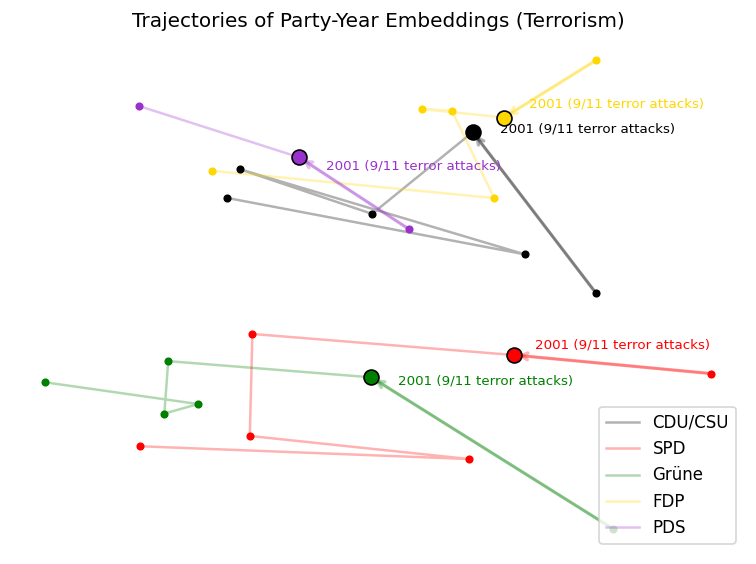

In [13]:
plot_trajectory(df_9_11, 2001, [2000, 2005], 'Terrorism', '9/11 terror attacks')


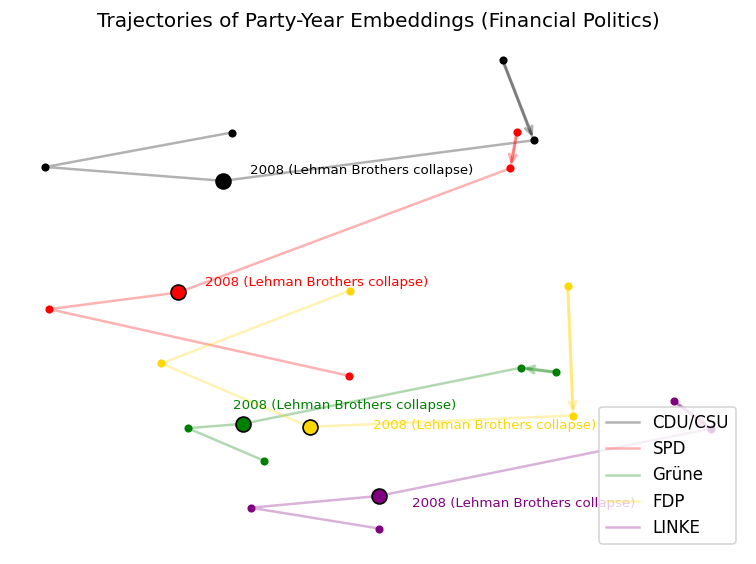

In [14]:
plot_trajectory(df_financial_crisis, 2008, [2006, 2010], 'Financial Politics', 'Lehman Brothers collapse')


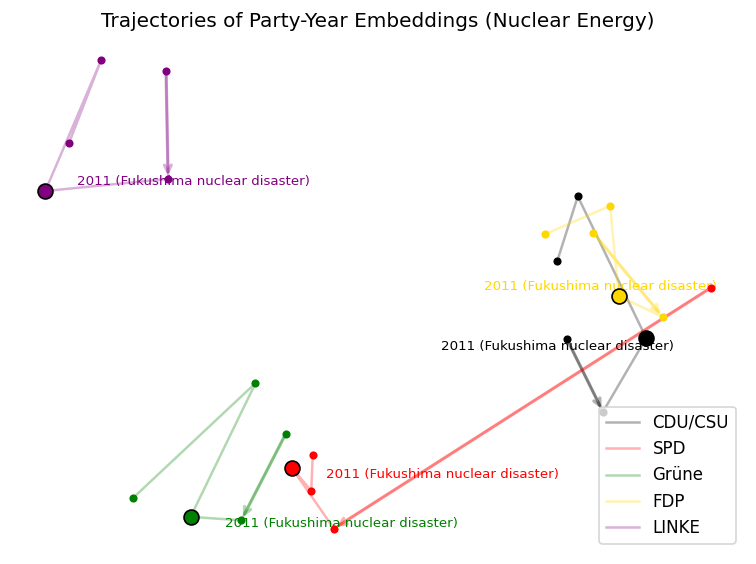

In [15]:
plot_trajectory(df_fukushima, 2011, [2009, 2013], 'Nuclear Energy', 'Fukushima nuclear disaster')


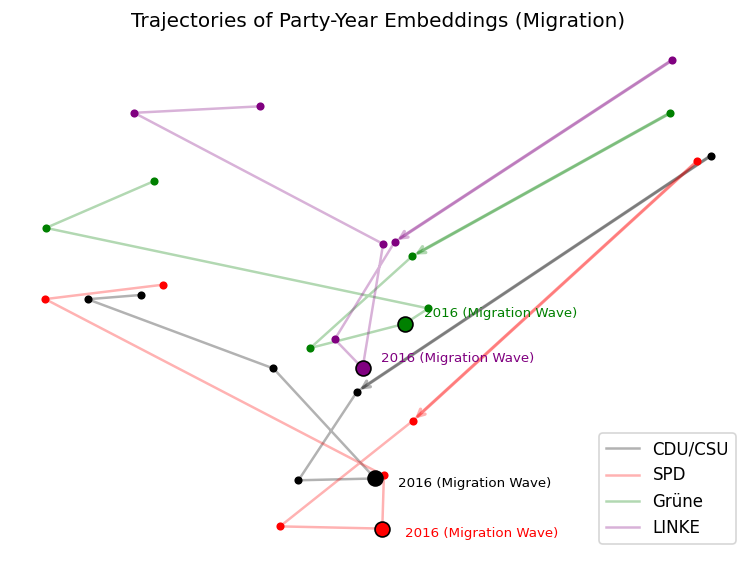

In [16]:
plot_trajectory(df_migration, 2016, [2013, 2019], 'Migration', 'Migration Wave')


Since the trajectories in a single combined plot were hard to read, we split this up and create one 2D PCA trajectory plot per party instead, covering the party's full time range (not restricted to the event window).


In [17]:
def plot_trajectory_per_party(df, year, topic, crisis, timespan):

    # restrict to the years around the event, same as plot_trajectory,
    # so the PCA is fit on the same data and trajectories are comparable
    df = df[(df["year"] >= timespan[0]) & (df["year"] <= timespan[1])]

    # aggregate the filtered embeddings by party and year
    df_agg = aggregate_by_party_year(df)

    # stack embeddings to array
    stack = np.stack(df_agg['embedding'])

    # PCA to reduce embedding space to two dimensions (fit once, across all parties)
    pca_traj = PCA(n_components=2)
    pcs_traj = pca_traj.fit_transform(stack)

    # data frame for plot
    df_party_trajectories = pd.DataFrame({
        "dim1": pcs_traj[:, 0],
        "dim2": pcs_traj[:, 1],
        "party": df_agg.party,
        "year": df_agg.year
    })

    df_party_trajectories = df_party_trajectories.sort_values(["party", "year"])

    # one plot per party
    for party, color in party_colors.items():
        subset = df_party_trajectories[df_party_trajectories["party"] == party]

        # skip parties with no speech in the event year itself
        if year not in subset["year"].values:
            continue

        fig, ax = plt.subplots(figsize=(6, 5))

        # line between points stays faint, markers on top stay fully opaque
        ax.plot(subset["dim1"], subset["dim2"], color=color, alpha=0.3)
        ax.scatter(subset["dim1"], subset["dim2"], color=color, s=15, zorder=4)

        # arrows between all consecutive points, to show the full trajectory direction
        for i in range(len(subset) - 1):
            ax.annotate('', xy=(subset["dim1"].iloc[i+1], subset["dim2"].iloc[i+1]),
                            xytext=(subset["dim1"].iloc[i], subset["dim2"].iloc[i]),
                            arrowprops=dict(arrowstyle='->', color=color, lw=1.5, alpha=0.3))

        # collect labels for adjustText instead of placing them with a fixed offset
        texts = []
        for i in range(len(subset)):
            yr = subset["year"].iloc[i]
            label = f"{yr} ({crisis})" if yr == year else str(yr)
            texts.append(ax.text(subset["dim1"].iloc[i], subset["dim2"].iloc[i],
                                 label, fontsize=8, color=color))

        adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color=color, lw=0.5))

        # highlight the event year
        year_row = subset[subset["year"] == year]
        ax.scatter(year_row["dim1"], year_row["dim2"], color=color,
                   s=80, edgecolors="black", zorder=5)

        ax.axis("off")
        ax.set_title(f"{party} — Trajectory of Year Embeddings ({topic})")
        plt.tight_layout()
        plt.show()


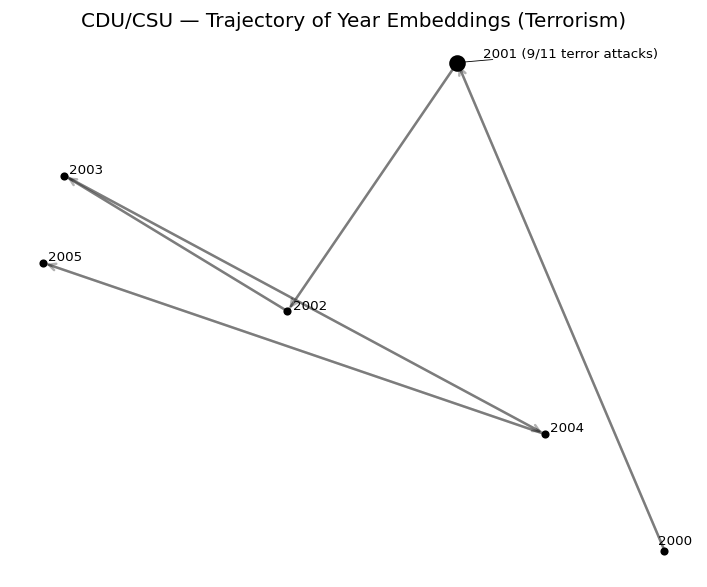

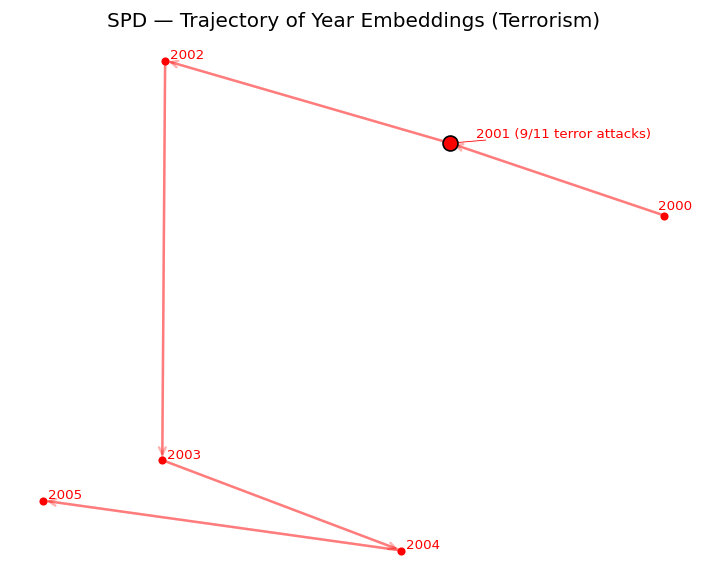

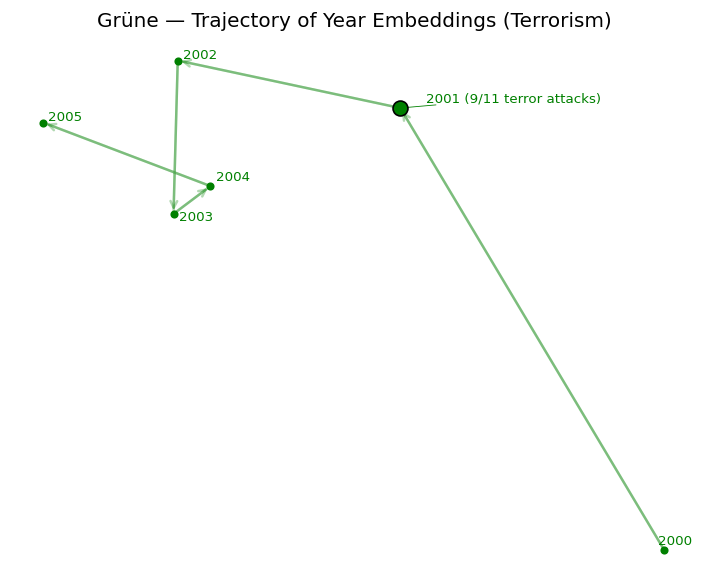

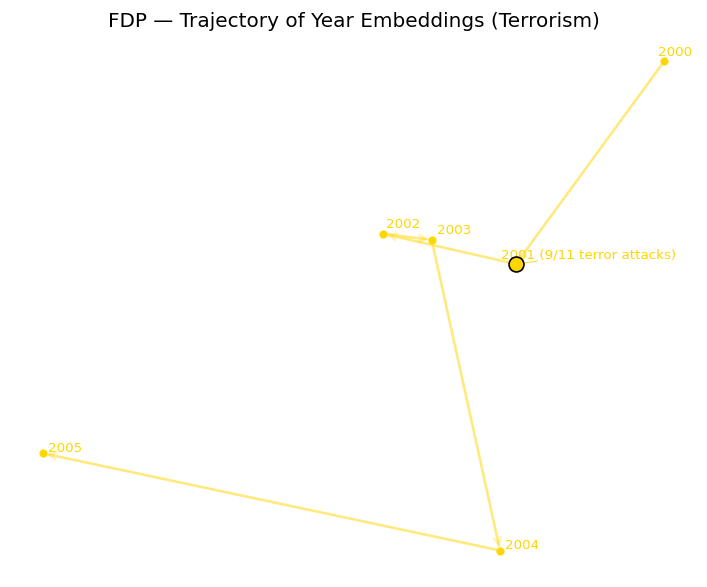

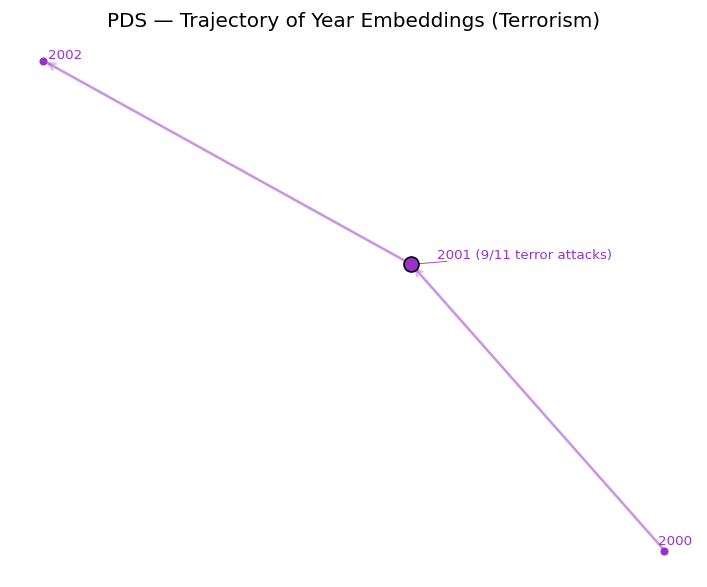

In [54]:
plot_trajectory_per_party(df_9_11, 2001, 'Terrorism', '9/11 terror attacks', [2000, 2005])


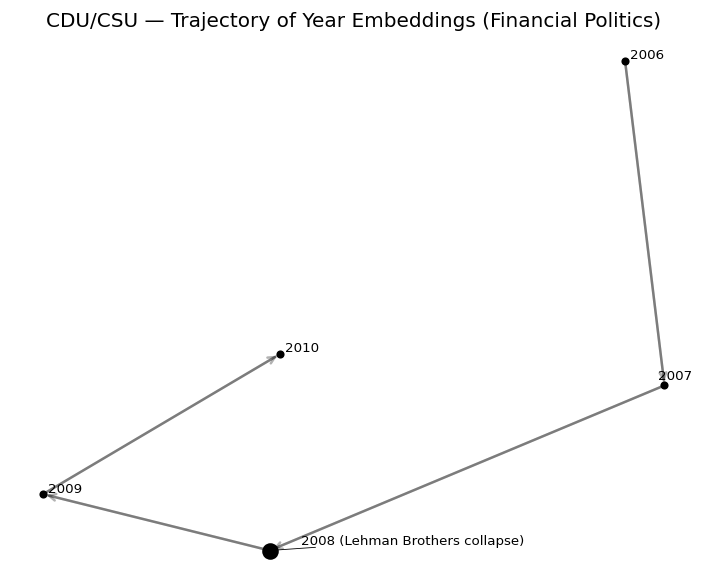

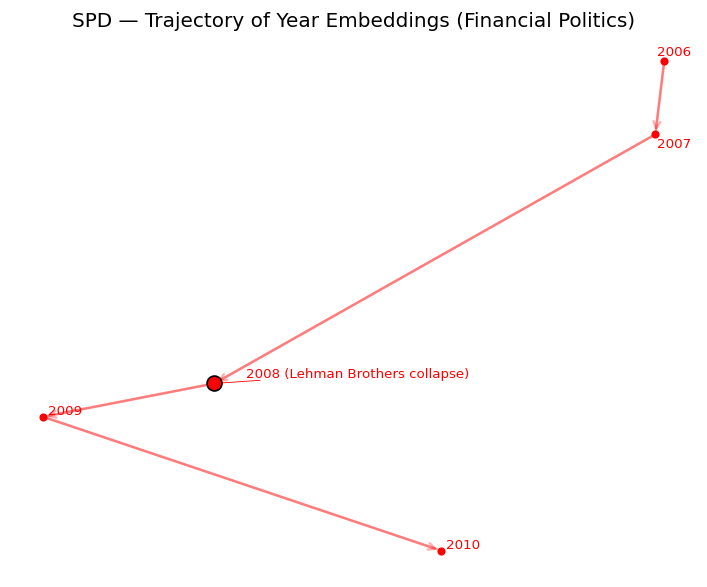

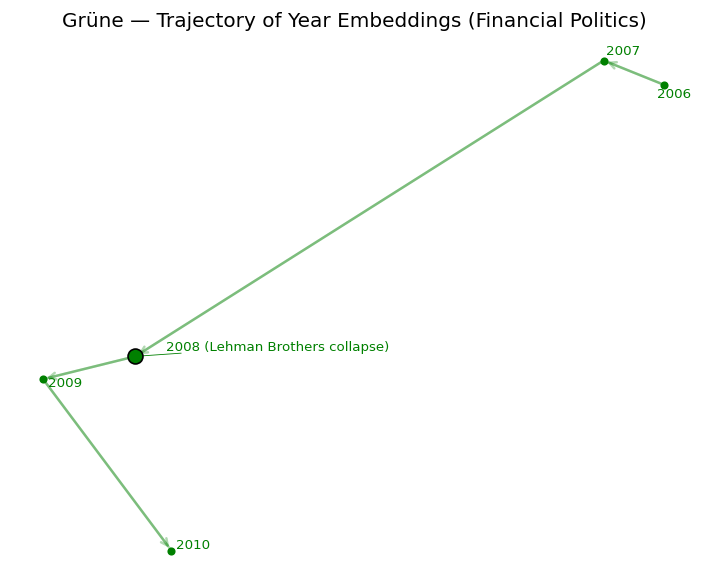

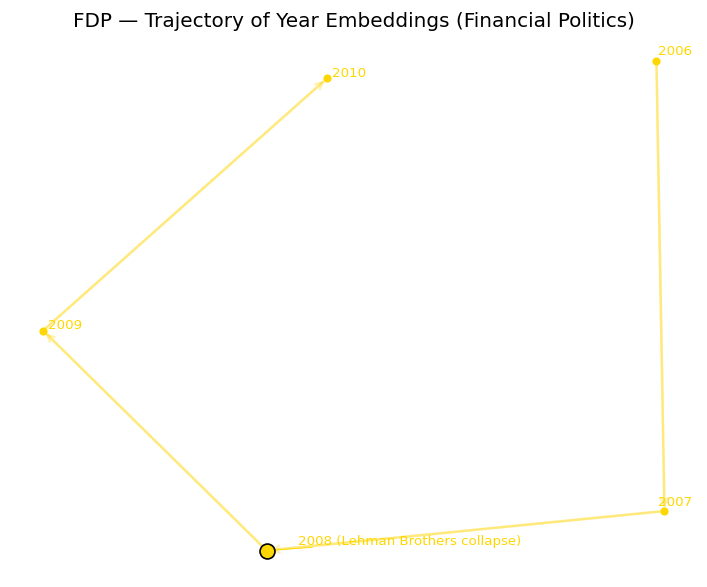

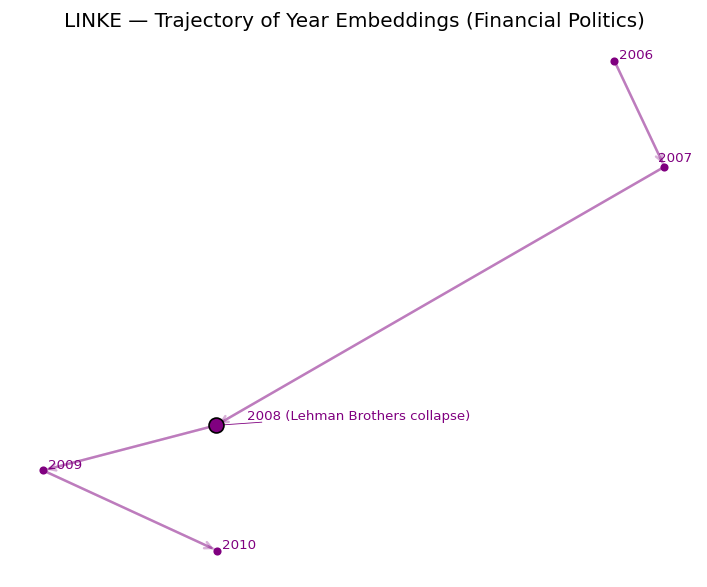

In [19]:
plot_trajectory_per_party(df_financial_crisis, 2008, 'Financial Politics', 'Lehman Brothers collapse', [2006, 2010])


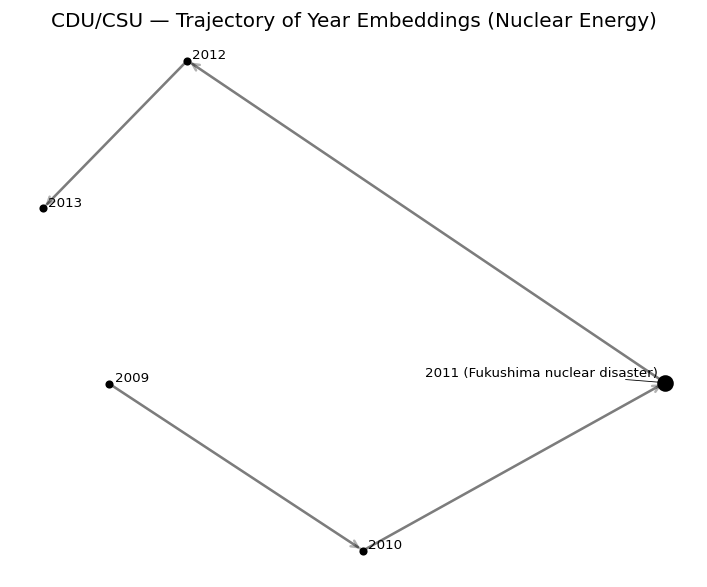

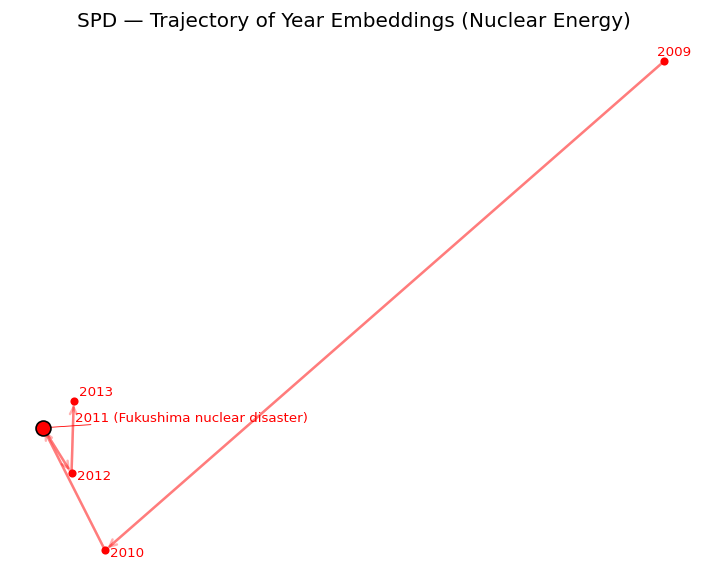

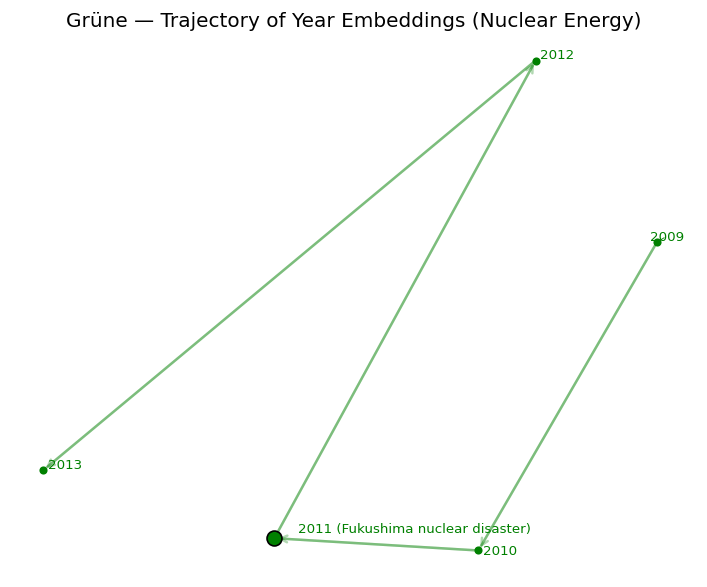

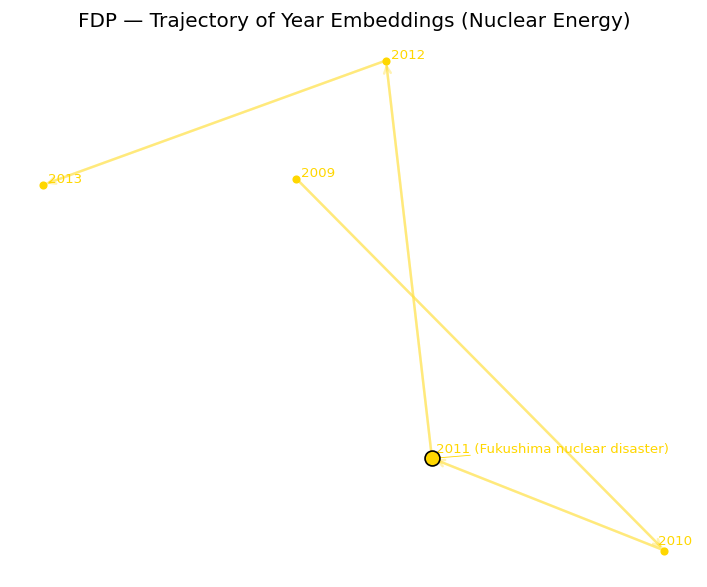

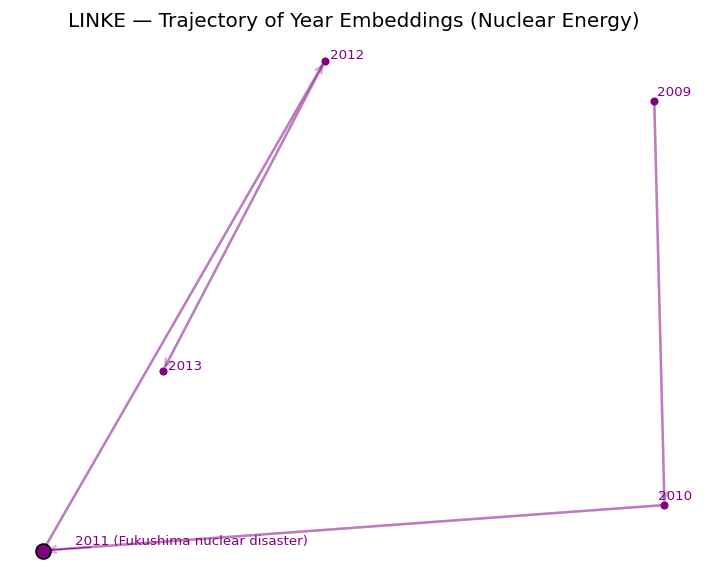

In [20]:
plot_trajectory_per_party(df_fukushima, 2011, 'Nuclear Energy', 'Fukushima nuclear disaster', [2009, 2013])


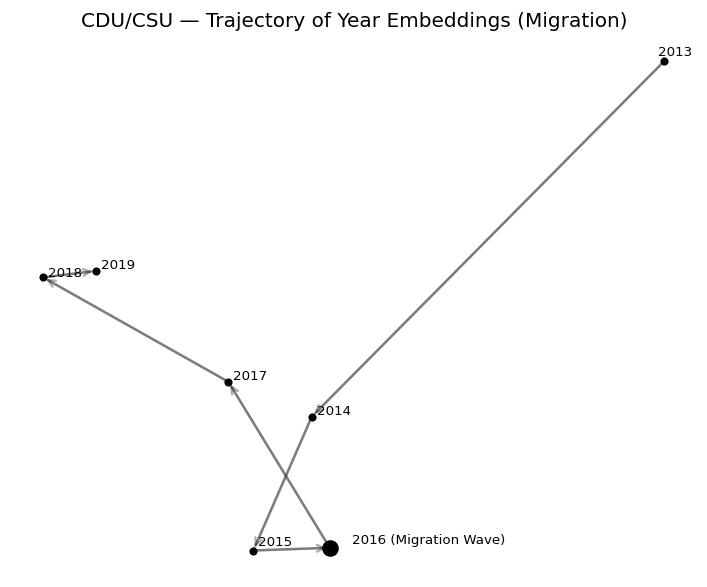

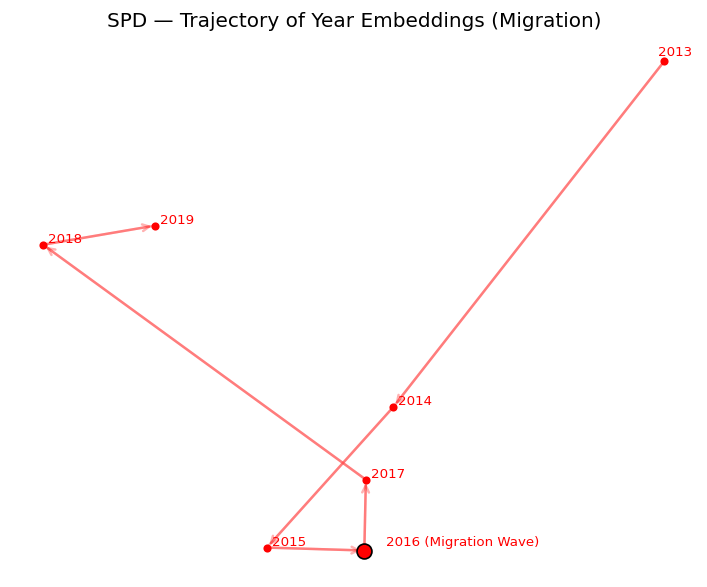

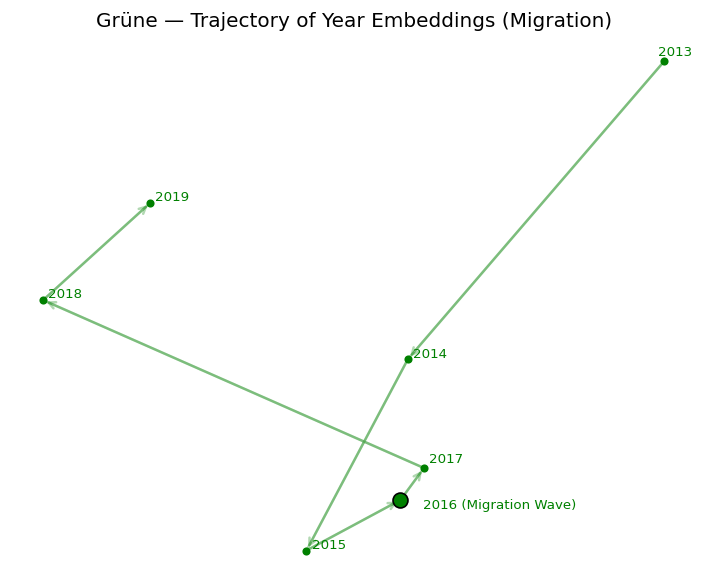

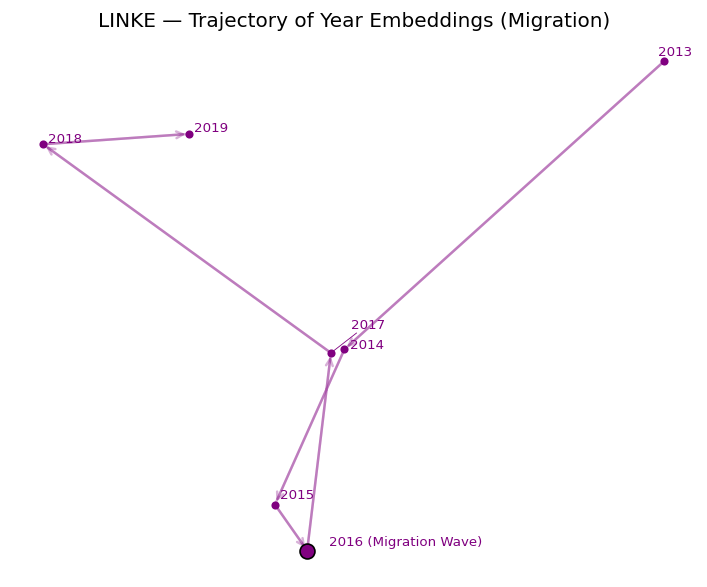

In [21]:
plot_trajectory_per_party(df_migration, 2016, 'Migration', 'Migration Wave', [2013, 2019])


To make the time axis easier to interpret, we reduce the embedding space to a single dimension (PC1) instead of two, and plot each party's PC1 value over the years directly, with the event year marked by a vertical line.


In [22]:
def plot_trajectory_1d(df, year, topic, crisis):

    # aggregate the embeddings by party and year
    df_agg = aggregate_by_party_year(df)

    # stack embeddings to array
    stack = np.stack(df_agg['embedding'])

    # PCA to reduce embedding space to one dimension
    pca_traj = PCA(n_components=1)
    pcs_traj = pca_traj.fit_transform(stack)

    # data frame for plot
    df_party_trajectories = pd.DataFrame({
        "pc1": pcs_traj[:, 0],
        "party": df_agg.party,
        "year": df_agg.year
    })

    df_party_trajectories = df_party_trajectories.sort_values(["party", "year"])

    fig, ax = plt.subplots()

    for party, color in party_colors.items():
        subset = df_party_trajectories[df_party_trajectories["party"] == party]

        # skip parties with no speech in the event year itself
        if year not in subset["year"].values:
            continue

        ax.plot(subset["year"], subset["pc1"], color=color, label=party, marker='o', markersize=3)

    # mark the event year and label it
    ax.axvline(year, color="grey", linestyle="--", linewidth=1)
    ax.annotate(crisis, (year, ax.get_ylim()[1]), xytext=(3, -10),
                textcoords="offset points", fontsize=8, color="0.2")

    # force integer year ticks
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    ax.set_xlabel("Year")
    ax.set_ylabel("PC1")
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
    ax.set_title(f"PC1 of Party-Year Embeddings over Time ({topic})")
    plt.tight_layout()
    plt.show()


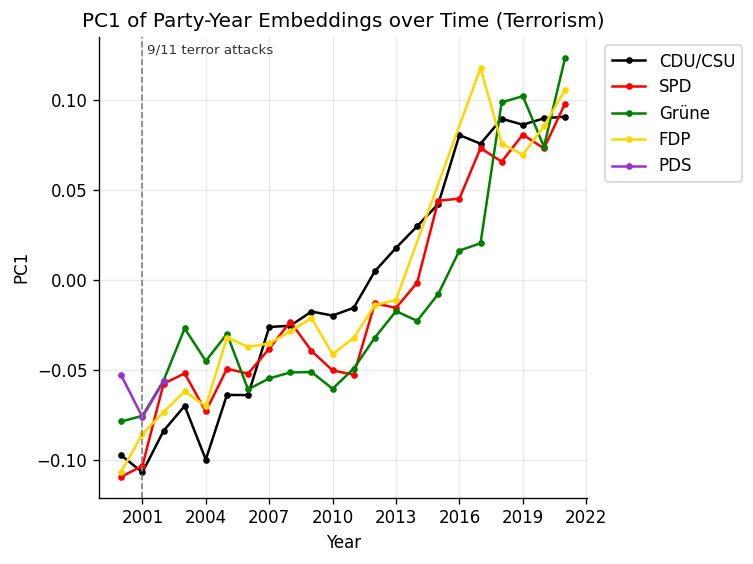

In [23]:
plot_trajectory_1d(df_9_11, 2001, 'Terrorism', '9/11 terror attacks')


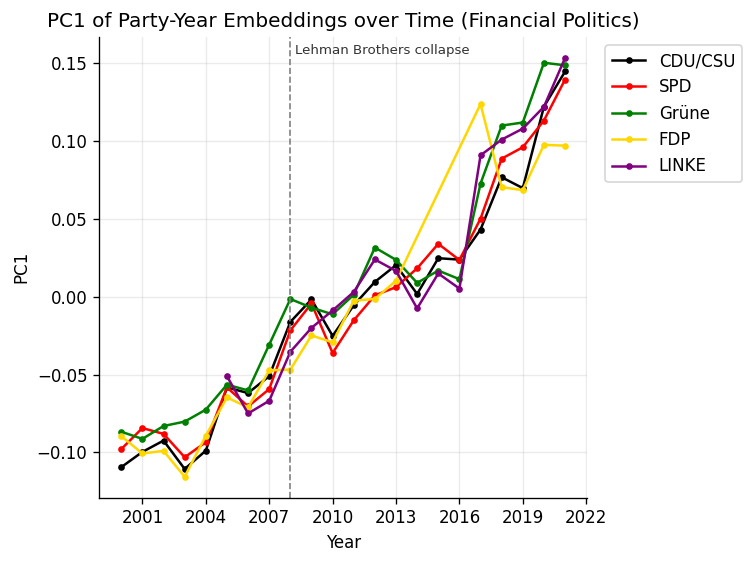

In [24]:
plot_trajectory_1d(df_financial_crisis, 2008, 'Financial Politics', 'Lehman Brothers collapse')


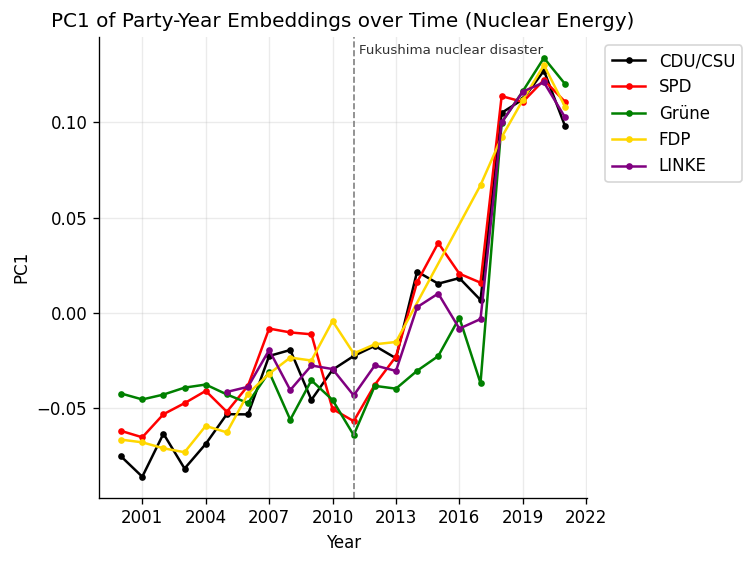

In [25]:
plot_trajectory_1d(df_fukushima, 2011, 'Nuclear Energy', 'Fukushima nuclear disaster')


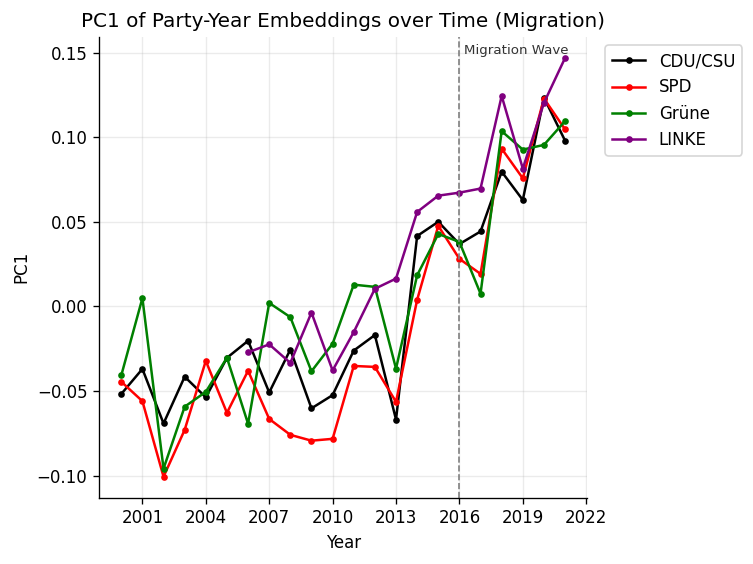

In [26]:
plot_trajectory_1d(df_migration, 2016, 'Migration', 'Migration Wave')


In [27]:
def demean_by_year(df_traj, value_col="pc1"):
    """Subtracts the across-party mean per year from the given value column."""
    df_traj = df_traj.copy()
    year_means = df_traj.groupby("year")[value_col].transform("mean")
    df_traj[f"{value_col}_demeaned"] = df_traj[value_col] - year_means
    return df_traj

To rule out that a shared, year-wide shift in language (rather than a party-specific move) is driving the pattern, we subtract each year's across-party mean from PC1 before plotting, so only each party's position relative to the others in that year remains.


In [28]:
def plot_trajectory_1d_demeaned(df, year, topic, crisis):

    # aggregate the embeddings by party and year
    df_agg = aggregate_by_party_year(df)

    # stack embeddings to array
    stack = np.stack(df_agg['embedding'])

    # PCA to reduce embedding space to one dimension
    pca_traj = PCA(n_components=1)
    pcs_traj = pca_traj.fit_transform(stack)

    # data frame for plot
    df_party_trajectories = pd.DataFrame({
        "pc1": pcs_traj[:, 0],
        "party": df_agg.party,
        "year": df_agg.year
    })

    df_party_trajectories = df_party_trajectories.sort_values(["party", "year"])

    # subtract the across-party mean per year (to remove common, year-wide shifts)
    df_party_trajectories = demean_by_year(df_party_trajectories, value_col="pc1")

    fig, ax = plt.subplots()

    for party, color in party_colors.items():
        subset = df_party_trajectories[df_party_trajectories["party"] == party]

        # skip parties with no speech in the event year itself
        if year not in subset["year"].values:
            continue

        ax.plot(subset["year"], subset["pc1_demeaned"], color=color, label=party, marker='o', markersize=3)

    # mark the event year and label it
    ax.axvline(year, color="grey", linestyle="--", linewidth=1)
    ax.annotate(crisis, (year, ax.get_ylim()[1]), xytext=(3, -10),
                textcoords="offset points", fontsize=8, color="0.2")

    # force integer year ticks
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    ax.set_xlabel("Year")
    ax.set_ylabel("PC1 (demeaned per year)")
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
    ax.set_title(f"PC1 of Party-Year Embeddings over Time, Demeaned ({topic})")
    plt.tight_layout()
    plt.show()


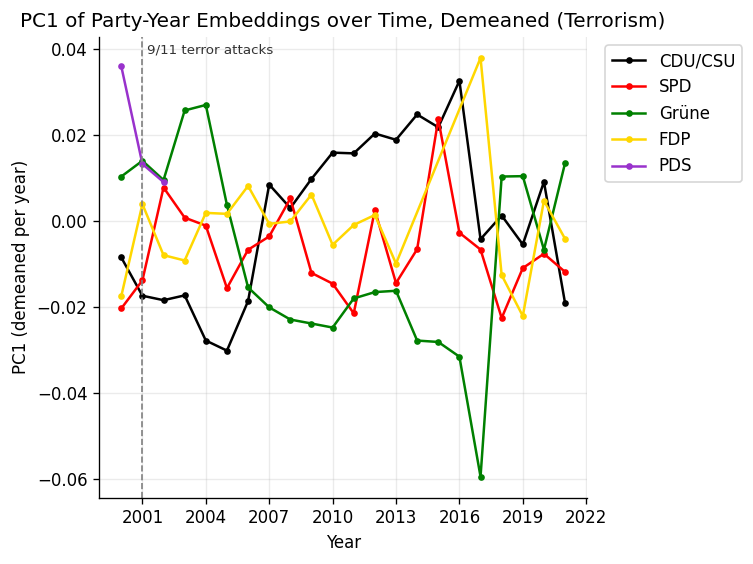

In [29]:
plot_trajectory_1d_demeaned(df_9_11, 2001, "Terrorism", '9/11 terror attacks')


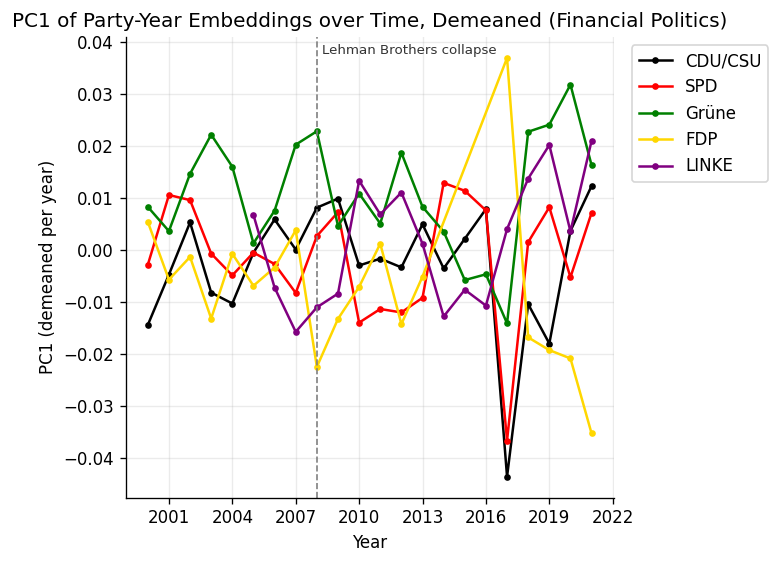

In [30]:
plot_trajectory_1d_demeaned(df_financial_crisis, 2008, "Financial Politics", 'Lehman Brothers collapse')


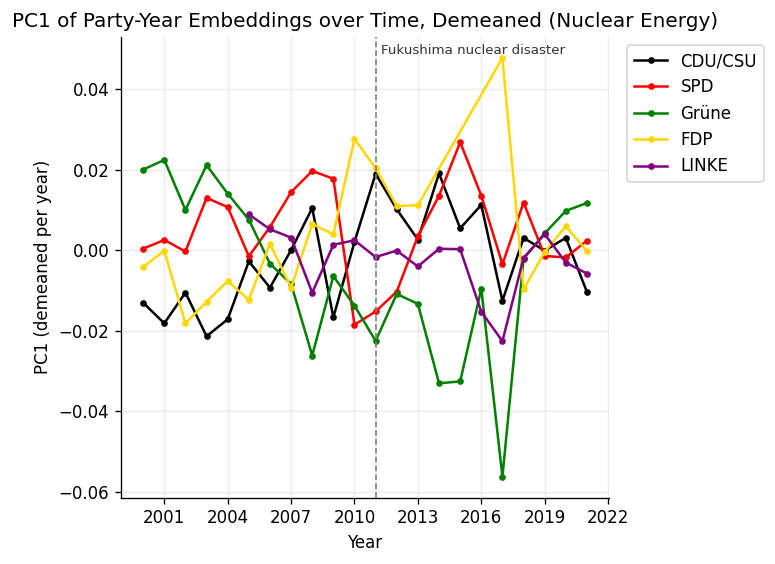

In [31]:
plot_trajectory_1d_demeaned(df_fukushima, 2011, "Nuclear Energy", 'Fukushima nuclear disaster')


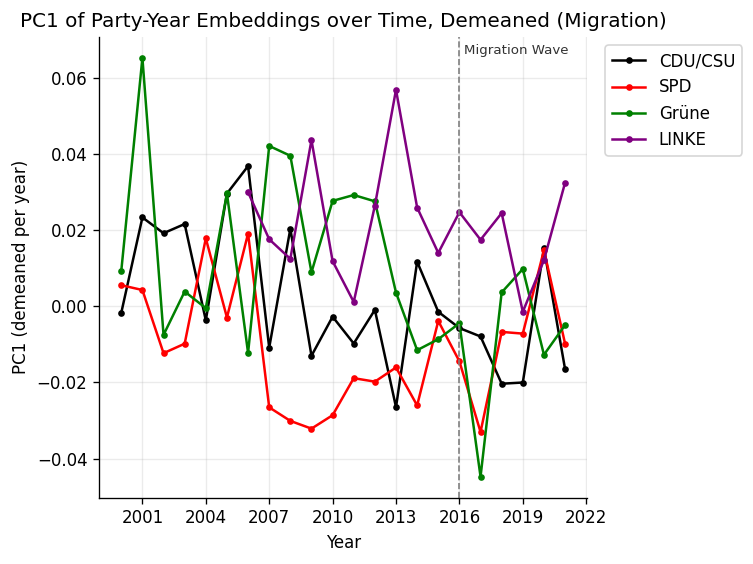

In [32]:
plot_trajectory_1d_demeaned(df_migration, 2016, "Migration", 'Migration Wave')


We therefore try two alternative approaches to the visual inspection of party trajectories:
- instead of tracking whole parties, we focus on individual politicians who specialized in the respective topic
- instead of relying on a visual check, we compute the cosine similarity between consecutive embeddings and look for peaks in the resulting distance, indicating unusually large shifts.


In [33]:
def find_specialist_per_party(data, topic_name, year):
    """
    For a given topic and year: pick the politician with the most speeches on
    this topic per party (including name), restricted to politicians who
    actually spoke on this topic in the given event year.
    """
    topic_speeches = data[data["topic_emb_raw_name"] == topic_name]

    # only politicians active on this topic in the event year itself qualify
    active_in_year = set(
        topic_speeches.loc[topic_speeches["year"] == year, "politicianId"]
    )
    topic_speeches = topic_speeches[topic_speeches["politicianId"].isin(active_in_year)]

    specialists = {}
    for party, group in topic_speeches.groupby("party"):
        top_politician = group["politicianId"].value_counts().idxmax()
        top_name = group.loc[group["politicianId"] == top_politician, "politicianName"].iloc[0]
        specialists[party] = {"politicianId": top_politician, "name": top_name}

    return specialists


In [34]:
# the first (main) topic of each event defines its specialists
specialists_9_11 = find_specialist_per_party(df_embeddings_topics, TOPICS_9_11[0], 2001)
specialists_finance = find_specialist_per_party(df_embeddings_topics, TOPICS_FINANCE[0], 2008)
specialists_nuclear_energy = find_specialist_per_party(df_embeddings_topics, TOPICS_FUKUSHIMA[0], 2011)
specialists_migration = find_specialist_per_party(df_embeddings_topics, TOPICS_MIGRATION[0], 2016)


In [35]:
def get_specialist_trajectories(data, specialists):
    """specialists: Dict {party: {"politicianId": ..., "name": ...}} aus find_specialist_per_party."""
    politician_ids = [s["politicianId"] for s in specialists.values()]
    id_to_name = {s["politicianId"]: s["name"] for s in specialists.values()}

    df_specialists = data[data["politicianId"].isin(politician_ids)]
    df_traj = aggregate_by_mp_year(df_specialists)
    df_traj["politicianName"] = df_traj["politicianId"].map(id_to_name)
    return df_traj


In [36]:
df_specialists_9_11 = get_specialist_trajectories(df_9_11, specialists_9_11)
df_specialists_9_11

,politicianId,year,party,n_speeches,embedding,politicianName
0,11001180,2000,FDP,10,"[0.07358741, -0.1478721, 0.06182598, -0.004762...",jürgen koppelin
1,11001180,2001,FDP,7,"[0.05750292, -0.14661483, 0.05039869, -0.02663...",jürgen koppelin
2,11001180,2002,FDP,8,"[0.06551809, -0.12836927, 0.046915743, 0.00552...",jürgen koppelin
3,11001180,2003,FDP,4,"[0.034806397, -0.14136173, 0.053461127, -0.003...",jürgen koppelin
4,11001180,2004,FDP,3,"[0.044266194, -0.15829138, 0.06370818, -0.0169...",jürgen koppelin
...,...,...,...,...,...,...
71,11003152,2001,CDU/CSU,1,"[0.0897924, -0.21167703, 0.021133704, -0.00063...",Martin Hohmann
72,11003152,2003,CDU/CSU,1,"[0.032130137, -0.17650822, 0.099275686, 0.0606...",Martin Hohmann
73,11003152,2018,AfD,4,"[0.049579278, -0.14987367, 0.055604815, -0.011...",Martin Hohmann
74,11003152,2019,AfD,2,"[0.040915832, -0.14791188, 0.070458874, -0.015...",Martin Hohmann


In [37]:
df_specialists_finance = get_specialist_trajectories(df_financial_crisis, specialists_finance)
df_specialists_finance

,politicianId,year,party,n_speeches,embedding,politicianName
0,11000921,2000,PDS,9,"[0.059650123, -0.0758905, 0.013587915, 0.00572...",barbara höll
1,11000921,2001,PDS,10,"[0.057292305, -0.07789811, 0.027127773, 0.0007...",barbara höll
2,11000921,2002,PDS,7,"[0.05736616, -0.090811156, 0.027597683, 0.0206...",barbara höll
3,11000921,2005,LINKE,3,"[0.04872191, -0.05655377, 0.012152378, 0.02922...",barbara höll
4,11000921,2006,LINKE,18,"[0.055395707, -0.07343403, 0.03379464, 0.01779...",barbara höll
...,...,...,...,...,...,...
74,11003837,2014,Grüne,9,"[0.09067932, -0.06857446, -0.008261606, -0.007...",Gerhard Schick
75,11003837,2015,Grüne,10,"[0.095024735, -0.076072596, -0.0015632908, -0....",Gerhard Schick
76,11003837,2016,Grüne,12,"[0.09676173, -0.10487964, 0.015693285, -0.0080...",Gerhard Schick
77,11003837,2017,Grüne,4,"[0.08913572, -0.07610387, 0.009087905, -0.0120...",Gerhard Schick


In [38]:
df_specialists_fukushima = get_specialist_trajectories(df_fukushima, specialists_nuclear_energy)
df_specialists_fukushima

,politicianId,year,party,n_speeches,embedding,politicianName
0,11002636,2000,PDS,29,"[0.08071459, -0.11760782, 0.040602244, -0.0235...",eva bulling-schröter
1,11002636,2001,PDS,12,"[0.076447845, -0.116159834, 0.038874432, -0.02...",eva bulling-schröter
2,11002636,2002,PDS,11,"[0.07347641, -0.14299063, 0.046686534, -0.0322...",eva bulling-schröter
3,11002636,2005,LINKE,2,"[0.0887623, -0.09703824, 0.046291158, -0.01623...",eva bulling-schröter
4,11002636,2006,LINKE,13,"[0.06891127, -0.110709116, 0.04062388, -0.0259...",eva bulling-schröter
...,...,...,...,...,...,...
61,11004081,2017,Grüne,11,"[0.07380884, -0.14699942, 0.048076227, -0.0003...",Oliver Krischer
62,11004081,2018,Grüne,25,"[0.046658736, -0.13916393, 0.03634237, -0.0121...",Oliver Krischer
63,11004081,2019,Grüne,21,"[0.069318704, -0.12454128, 0.02777545, -0.0191...",Oliver Krischer
64,11004081,2020,Grüne,15,"[0.07643287, -0.10392053, 0.028695293, -0.0266...",Oliver Krischer


In [39]:
df_specialists_migration = get_specialist_trajectories(df_migration, specialists_migration)
df_specialists_migration

,politicianId,year,party,n_speeches,embedding,politicianName
0,11001023,2000,PDS,9,"[0.026877591, -0.14642826, 0.080866024, 0.0143...",ulla jelpke
1,11001023,2001,PDS,4,"[0.020337688, -0.14675927, 0.081776455, 0.0125...",ulla jelpke
2,11001023,2006,LINKE,4,"[0.0032662828, -0.13357493, 0.09007467, -0.007...",ulla jelpke
3,11001023,2007,LINKE,6,"[0.028673554, -0.15130492, 0.09942752, 0.00795...",ulla jelpke
4,11001023,2008,LINKE,3,"[0.044260785, -0.14676593, 0.07625618, 0.00824...",ulla jelpke
...,...,...,...,...,...,...
57,11003589,2014,CDU/CSU,4,"[0.029130582, -0.1232682, 0.09527607, 0.032753...",Stephan Mayer
58,11003589,2015,CDU/CSU,7,"[0.0360136, -0.14167008, 0.0953799, 0.03721262...",Stephan Mayer
59,11003589,2016,CDU/CSU,10,"[0.04955908, -0.13128056, 0.08646698, 0.020973...",Stephan Mayer
60,11003589,2017,CDU/CSU,5,"[0.03464604, -0.13882908, 0.09931757, 0.026321...",Stephan Mayer


In [40]:
def plot_trajectory_1d_specialists(df, year, topic, crisis, specialists):
    df_agg = aggregate_by_mp_year(df)

    stack = np.stack(df_agg['embedding'])
    pca_traj = PCA(n_components=1)
    pcs_traj = pca_traj.fit_transform(stack)

    df_traj = pd.DataFrame({
        "pc1": pcs_traj[:, 0],
        "politicianId": df_agg.politicianId,
        "party": df_agg.party,
        "year": df_agg.year
    })
    df_traj = df_traj.sort_values(["politicianId", "year"])

    fig, ax = plt.subplots(figsize=(8, 5))

    for party, info in specialists.items():
        politician_id = info["politicianId"]
        name = info["name"]
        subset = df_traj[df_traj["politicianId"] == politician_id]

        # skip specialists with no speech in the event year itself
        if year not in subset["year"].values:
            continue

        # connecting line across all years, in the color of the party 
        ax.plot(subset["year"], subset["pc1"], color=party_colors[party],
                lw=1, alpha=0.8, zorder=2)

        # markers colored by the MP's ACTUAL party in that year, so a party
        # switch (e.g. PDS -> LINKE) is visible as a color change
        for actual_party, g in subset.groupby("party"):
            ax.scatter(g["year"], g["pc1"], color=party_colors.get(actual_party, "grey"),
                       s=20, zorder=3)

        # one legend entry per specialist, labeled by the party they were selected for
        ax.plot([], [], color=party_colors[party], marker='o', markersize=4,
                label=f"{party} ({name})")

    # mark the event year and label it
    ax.axvline(year, color="grey", linestyle="--", linewidth=1)
    ax.annotate(crisis, (year, ax.get_ylim()[1]), xytext=(3, -10),
                textcoords="offset points", fontsize=8, color="0.2")

    # force integer year ticks
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    ax.set_xlabel("Year")
    ax.set_ylabel("PC1")
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)
    ax.set_title(f"PC1 of Specialist MP Embeddings over Time ({topic})")
    plt.tight_layout()
    plt.show()


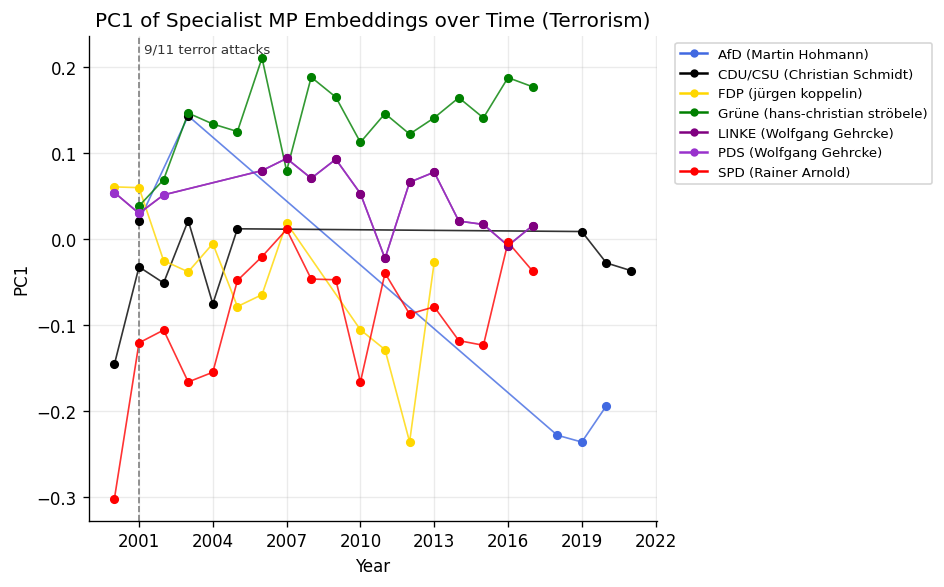

In [41]:
plot_trajectory_1d_specialists(df_specialists_9_11, 2001, 'Terrorism', '9/11 terror attacks', specialists_9_11)


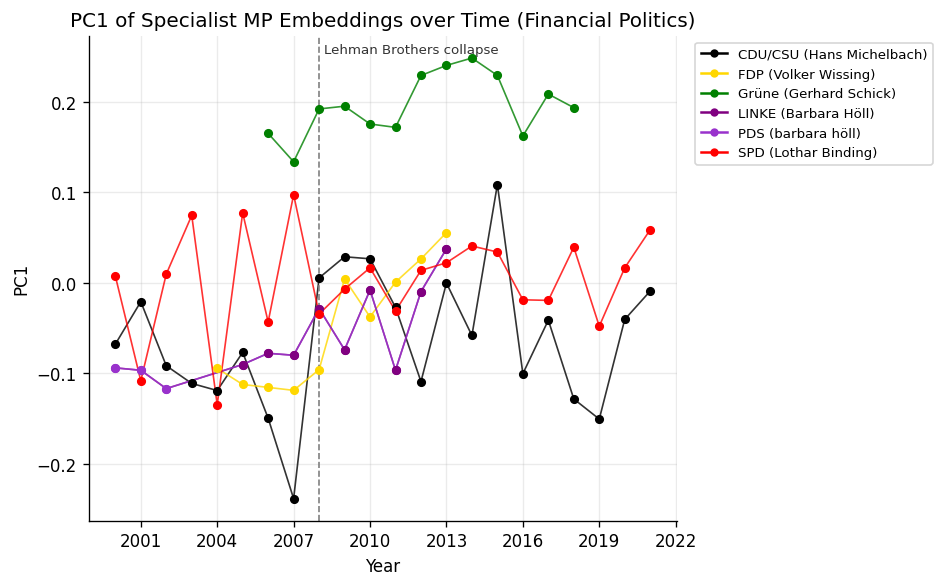

In [42]:
plot_trajectory_1d_specialists(df_specialists_finance, 2008, 'Financial Politics', 'Lehman Brothers collapse', specialists_finance)


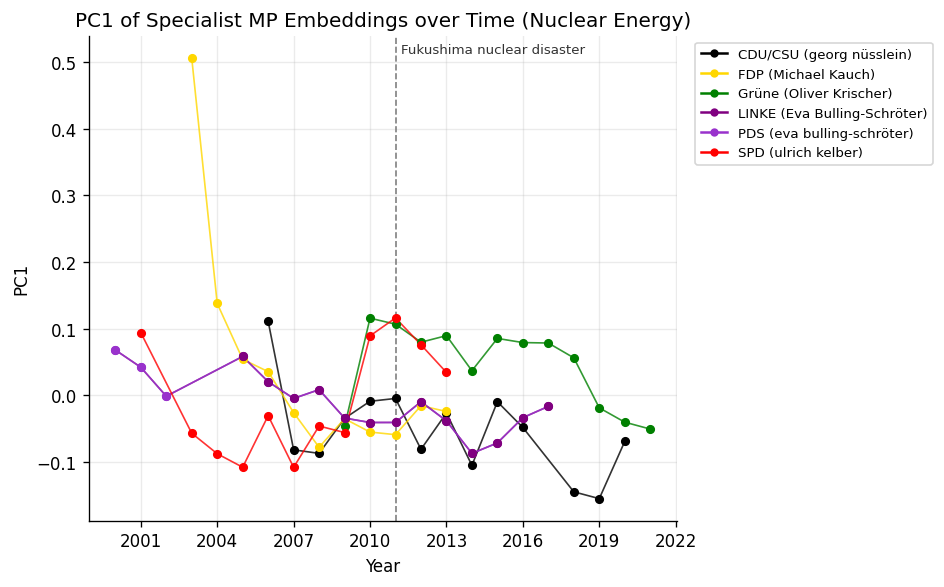

In [43]:
plot_trajectory_1d_specialists(df_specialists_fukushima, 2011, 'Nuclear Energy', 'Fukushima nuclear disaster', specialists_nuclear_energy)


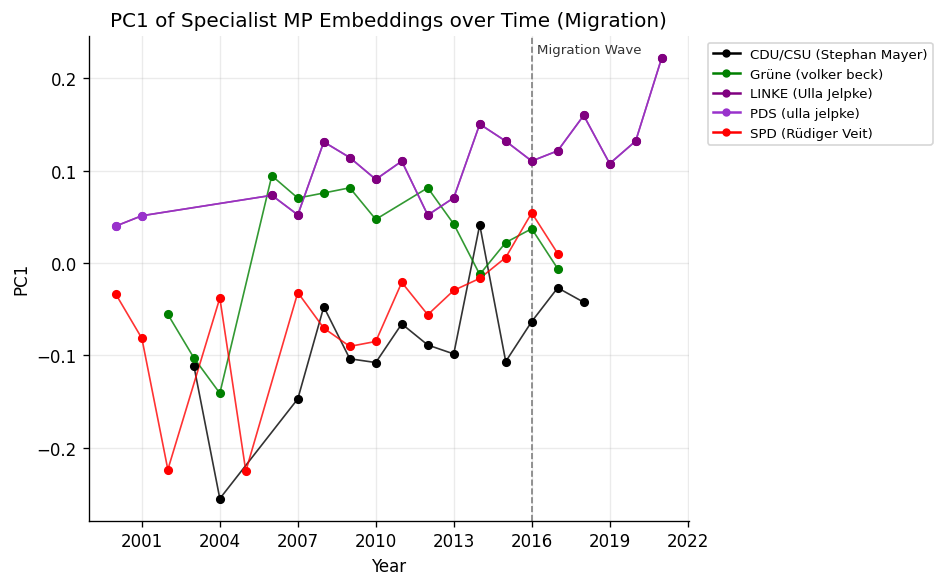

In [44]:
plot_trajectory_1d_specialists(df_specialists_migration, 2016, 'Migration', 'Migration Wave', specialists_migration)


### Cosine Similarity

In [45]:
def compute_distance_series(df, topic):
    """
    Aggregates the (already topic-filtered) speeches by party and year,
    then computes the cosine distance between each party's embedding
    in consecutive years.
    """
    df_agg = aggregate_by_party_year(df)
    df_agg = df_agg.sort_values(["party", "year"])

    records = []
    for party, color in party_colors.items():
        subset = df_agg[df_agg["party"] == party].sort_values("year")
        if len(subset) < 2:
            continue

        embeddings = np.stack(subset["embedding"])
        years = subset["year"].values

        for i in range(1, len(embeddings)):
            sim = cosine_similarity(embeddings[i-1].reshape(1, -1), embeddings[i].reshape(1, -1))[0, 0]
            distance = 1 - sim
            records.append({
                "party": party,
                "year": years[i],
                "distance": distance
            })

    return pd.DataFrame(records)

def plot_distance_series(df, topic, crisis, event_year):
    df_dist = compute_distance_series(df, topic)

    fig, ax = plt.subplots()

    for party, color in party_colors.items():
        subset = df_dist[df_dist["party"] == party]

        # skip parties with no distance value in the event year itself
        if event_year not in subset["year"].values:
            continue

        ax.plot(subset["year"], subset["distance"], color=color, label=party, marker='o', markersize=3)

    ax.axvline(event_year, color="grey", linestyle="--", linewidth=1)
    ax.annotate(crisis, (event_year, ax.get_ylim()[1]), xytext=(3, -10),
                textcoords="offset points", fontsize=8, color="0.2")

    ax.set_xlabel("Year")
    ax.set_ylabel("Cosine Distance to Previous Year")
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
    ax.set_title(f"Year-over-Year Embedding Distance ({topic})")
    ax.set_xticks(sorted(df_dist["year"].unique()))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return df_dist


There's no distance value for 2001 itself, because we're looking at year-over-year change. So the first value is for 2002. Therefor we leave out the 9/11 terror attacks for this part of the analysis. 


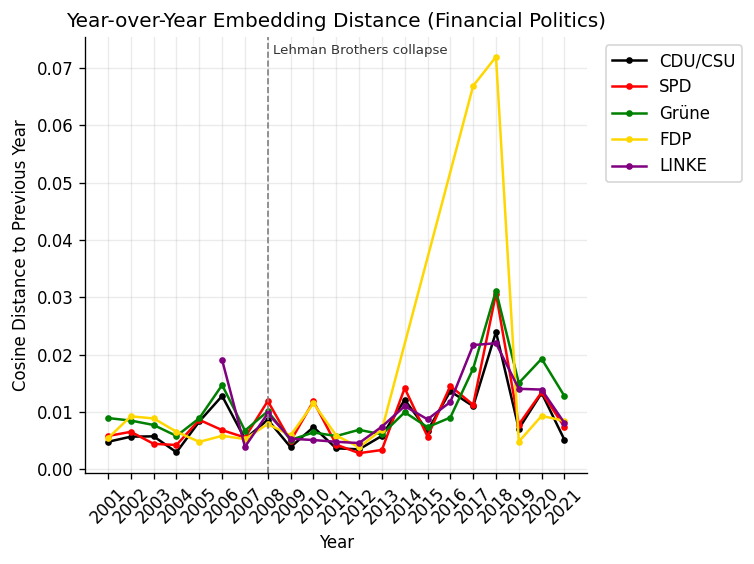

,party,year,distance
0,CDU/CSU,2001,0.004822
1,CDU/CSU,2002,0.005717
2,CDU/CSU,2003,0.005773
3,CDU/CSU,2004,0.002999
4,CDU/CSU,2005,0.008363
...,...,...,...
98,AfD,2019,0.006284
99,AfD,2020,0.012650
100,AfD,2021,0.007897
101,PDS,2001,0.011105


In [46]:
df_dist_finance = plot_distance_series(df_financial_crisis, "Financial Politics", 'Lehman Brothers collapse', 2008)
df_dist_finance


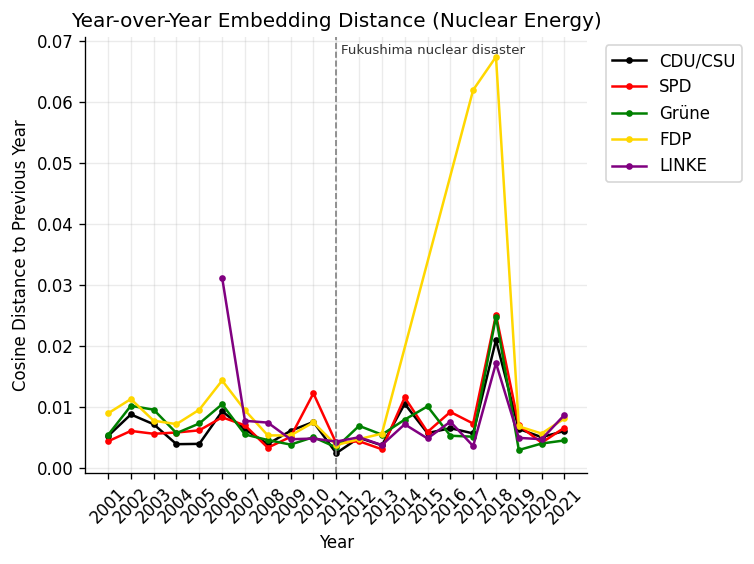

,party,year,distance
0,CDU/CSU,2001,0.005191
1,CDU/CSU,2002,0.008731
2,CDU/CSU,2003,0.007118
3,CDU/CSU,2004,0.003851
4,CDU/CSU,2005,0.003903
...,...,...,...
98,AfD,2019,0.005748
99,AfD,2020,0.004674
100,AfD,2021,0.005908
101,PDS,2001,0.008589


In [47]:
df_dist_fukushima = plot_distance_series(df_fukushima, "Nuclear Energy", 'Fukushima nuclear disaster', 2011)
df_dist_fukushima


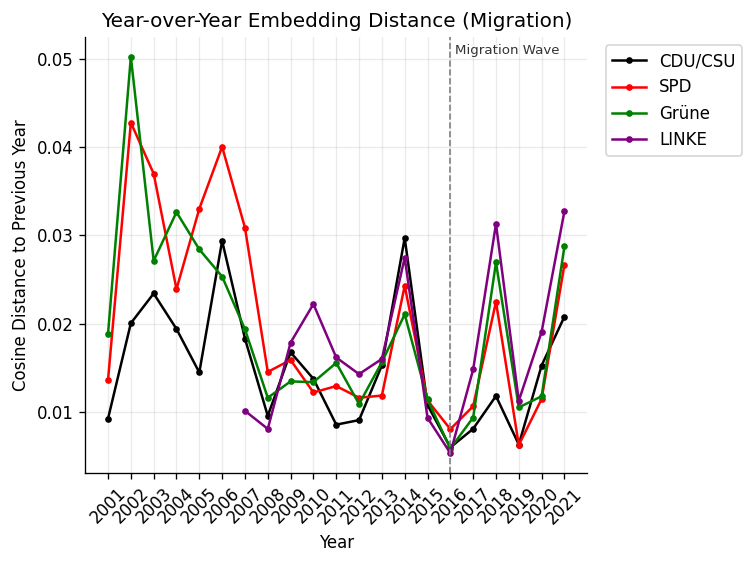

,party,year,distance
0,CDU/CSU,2001,0.009273
1,CDU/CSU,2002,0.020067
2,CDU/CSU,2003,0.023427
3,CDU/CSU,2004,0.019414
4,CDU/CSU,2005,0.014494
...,...,...,...
97,AfD,2019,0.006849
98,AfD,2020,0.007278
99,AfD,2021,0.015319
100,PDS,2001,0.020618


In [48]:
df_dist_migration = plot_distance_series(df_migration, "Migration", 'Migration Wave', 2016)
df_dist_migration


## 3. Party anchors — positions on an anchored axis

Part 2 asked where PCA puts the parties, and found that the dominant direction tracks era and
government/opposition rather than policy. This part replaces that with an axis we choose: two
parties are named as poles, and everyone else is projected onto the line between them.
Sample sizes behind these points are shown by marker size.

- yearly mean is subtracted so a drift shared by all parties cannot look like movement;
- the axis is estimated on the years before the event so the ruler does not move with the data; and the result is rescaled so the two anchor parties sit at 0 and 1 in that reference period, which makes a value of 0.4 readable as "40% of the way from one party's position to the other's"

In [49]:
def positions(topic_names, left, right, ref_years):
    "Party-year positions on the left->right axis, rescaled so left=0 and right=1 before the event."
    d = df[df.topic_emb_full_name.isin(topic_names)]

    # 1. aggregate to party-year, no threshold
    py = pd.DataFrame([dict(party=p, year=y, n=len(g),
                            E=np.mean(np.stack(g.E.to_numpy()), axis=0))
                       for (p, y), g in d.groupby(["party", "year"])])

    # a year with one party is useless: the yearly mean is that party, so demeaning gives 0
    per_year = py.groupby("year").size()
    lonely = per_year[per_year < 2].index.tolist()
    if lonely:
        print(f"years with only one party, dropped: {lonely}")
        py = py[~py.year.isin(lonely)]

    # 2. subtract the yearly mean
    ymu = {y: np.mean(np.stack(g.E.to_numpy()), axis=0) for y, g in py.groupby("year")}
    py["Ed"] = [e - ymu[y] for e, y in zip(py.E, py.year)]

    # 3. axis from the reference (pre-event) years only
    ref = py[py.year.isin(ref_years)]
    for anchor in (left, right):
        if not (ref.party == anchor).any():
            raise ValueError(f"{anchor} has no speech in the reference years {list(ref_years)}")
    a = (np.mean(np.stack(ref.loc[ref.party == right, "Ed"].to_numpy()), axis=0)
         - np.mean(np.stack(ref.loc[ref.party == left,  "Ed"].to_numpy()), axis=0))
    axis = a / np.linalg.norm(a)

    # 4. project, then rescale so the anchors sit at 0 and 1 in the reference period
    py["raw"] = [float(e @ axis) for e in py.Ed]
    lo = py.loc[py.year.isin(ref_years) & (py.party == left),  "raw"].mean()
    hi = py.loc[py.year.isin(ref_years) & (py.party == right), "raw"].mean()
    py["pos"] = (py.raw - lo) / (hi - lo)
    return py.sort_values(["party", "year"])


def plot_positions(py, event_year, left, right, title):
    fig, ax = plt.subplots(figsize=(9.5, 4.6))
    ax.axhline(0, color=PARTY_COLORS.get(left, "0.4"), ls=":", lw=1.4)
    ax.axhline(1, color=PARTY_COLORS.get(right, "0.4"), ls=":", lw=1.4)
    ax.axvline(event_year, color="#c0392b", ls="--", lw=1.5)
    for p, g in py.groupby("party"):
        g = g.sort_values("year")
        col = PARTY_COLORS.get(p, "grey")
        # break the line where a year is missing, so a gap is not drawn as a smooth move
        run = []
        for r in g.itertuples():
            if run and r.year - run[-1][0] > 1:
                ax.plot(*zip(*run), "-", color=col, lw=1.8)
                run = []
            run.append((r.year, r.pos))
        if len(run) > 1:
            ax.plot(*zip(*run), "-", color=col, lw=1.8)
        # marker size shows how many speeches are behind the point
        ax.scatter(g.year, g.pos, s=6 + 1.6 * g.n, color=col, zorder=4, label=p,
                   edgecolor="white", linewidth=.6)
    ax.set_xlabel("year")
    ax.set_ylabel(f"position on the {left} → {right} axis\n(0 = {left}, 1 = {right} before the event)")
    ax.set_title(title + "   (marker size = speeches behind the point)", loc="left", fontsize=10)
    ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.tight_layout()
    return ax

#### Fukushima — did the Union move toward the Greens?

The clearest test case, because the answer is documented outside the corpus: after March 2011
the CDU/CSU reversed course and legislated the nuclear phase-out it had extended only months
earlier. If the embeddings carry policy content, the Union should move upward after 2011. The
axis is estimated on 2005–2010.

speeches per party-year:
party  AfD  CDU/CSU  FDP  Grüne  LINKE  PDS  SPD
year                                            
2000     0      181   67     76      0   57  139
2001     0       93   43     55      0   36   85
2002     0       60   35     32      0   27   63
2003     0       87   37     40      0    0   58
2004     0      120   53     60      0    0   81
2005     0       88   33     40      4    0   56
2006     0       62   40     96     50    0   67
2007     0      100   81    120     73    0  101
2008     0       95   60    142     74    0   99
2009     0       82   58     99     66    0   72
2010     0      155   96    182     99    0  156
2011     0      152   95    151    121    0  145
2012     0      110   75    123    102    0  129
2013     0      100   52    136     88    0  102
2014     0      113    0    179     75    0   86
2015     0      104    0    210     76    0   85
2016     0      107    0    154     90    0   80
2017     5       63    2    110     58    0 

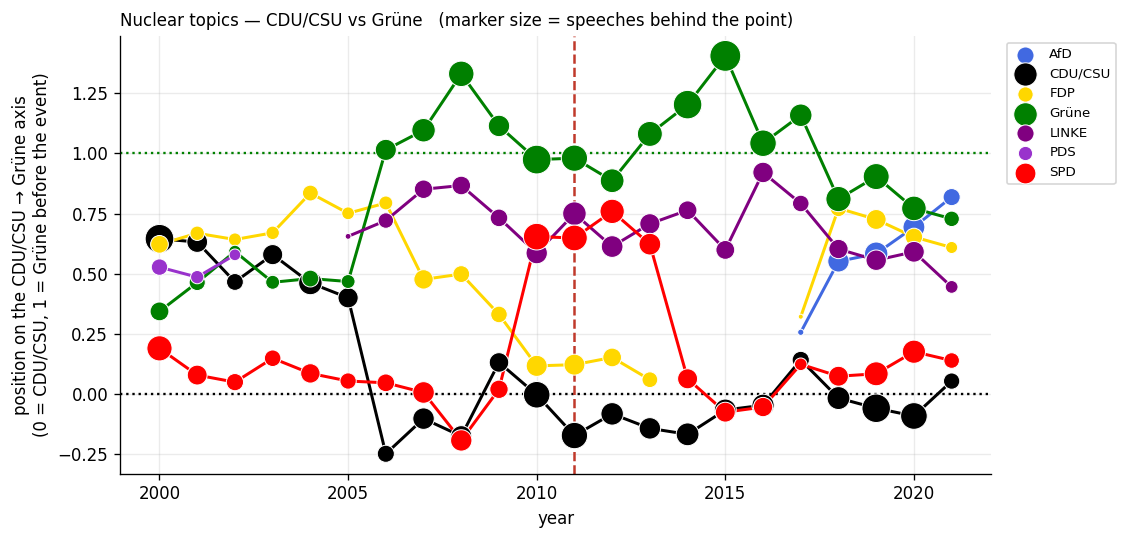

         2007-2010  2012-2015  shift
party                               
CDU/CSU      -0.04      -0.12  -0.08
FDP           0.36       0.11  -0.25
Grüne         1.13       1.14   0.01
LINKE         0.76       0.67  -0.09
SPD           0.12       0.34   0.22


In [50]:
NUCLEAR = TOPICS_FUKUSHIMA

py_nuc = positions(NUCLEAR, left="CDU/CSU", right="Grüne", ref_years=range(2005, 2011))
print("speeches per party-year:")
print(py_nuc.pivot(index="year", columns="party", values="n").fillna(0).astype(int).to_string())

plot_positions(py_nuc, 2011, "CDU/CSU", "Grüne", "Nuclear topics — CDU/CSU vs Grüne")
plt.savefig("fig_fukushima.png", dpi=150, bbox_inches="tight"); plt.show()

before = py_nuc[py_nuc.year.between(2007, 2010)].groupby("party").pos.mean()
after  = py_nuc[py_nuc.year.between(2012, 2015)].groupby("party").pos.mean()
print(pd.DataFrame({"2007-2010": before, "2012-2015": after,
                    "shift": after - before}).round(2).to_string())

#### Migration — where do the parties sit relative to the AfD?

The AfD only enters the Bundestag in 2017, so the axis has to be estimated *after* the event
rather than before it. That weakens the reading considerably: we can see the ordering of the
parties from 2017 onward, but not how they stood relative to a party that did not yet exist.

Anchors: Grüne und AfD

speeches per party-year:
party  AfD  CDU/CSU  FDP  Grüne  LINKE  PDS  SPD
year                                            
2000     0       31   23     20      0   17   29
2001     0       23    4      9      0    7   16
2002     0       10    2      8      0    4    4
2003     0       36    7      7      0    0   17
2004     0       30    9      9      0    0   12
2005     0       10    3      7      0    0   10
2006     0       14    7     12     16    0   10
2007     0       17   11     18     32    0   18
2008     0       15    8     22     18    0   22
2009     0       15   14     17     12    0   12
2010     0       29   15     18     24    0   13
2011     0       35   21     29     18    0   22
2012     0       19   19     23     16    0   18
2013     0       28   15     20     23    0   16
2014     0       36    0     45     31    0   37
2015     0       93    0     76     50    0   47
2016     0       74    0     69     44    0   43
2017     7       25    7     22     14    0 

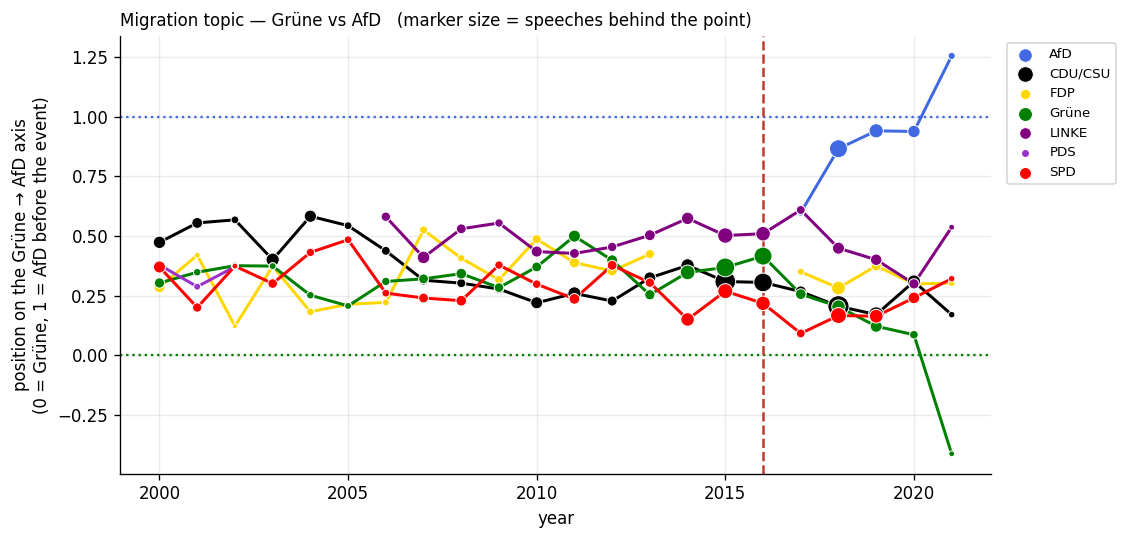

In [51]:
MIGRATION = TOPICS_MIGRATION

py_mig = positions(MIGRATION, left="Grüne", right="AfD", ref_years=range(2018, 2022))
print("speeches per party-year:")
print(py_mig.pivot(index="year", columns="party", values="n").fillna(0).astype(int).to_string())

plot_positions(py_mig, 2016, "Grüne", "AfD", "Migration topic — Grüne vs AfD")
plt.savefig("fig_migration.png", dpi=150, bbox_inches="tight"); plt.show()

## 4. Topic frequencies

Does an event change how much is said about a topic at all? This part never touches the embedding
vectors — only the topic labels and the speech counts behind them.

In [52]:
EVENTS = [
    #Afghanistan topics stand in for 9/11, since corpus records the parliamentary consequences rather than the attack
    dict(date="2001-09-11", label="9/11 terror attacks", kind="crisis", topics=TOPICS_9_11),
    dict(date="2008-09-15", label="Lehman collapse / financial crisis", kind="crisis", topics=TOPICS_FINANCE),
    dict(date="2011-03-11", label="Fukushima nuclear disaster", kind="crisis", topics=TOPICS_FUKUSHIMA),
    dict(date="2016-01-01", label="Migration scepticism (post-Cologne NYE)", kind="crisis", topics=TOPICS_MIGRATION),
]

for ev in EVENTS:
    ev["year"] = int(ev["date"][:4])
#checks that every name still exists in the data, so a re-run of the topic model would raise an error rather than silently analysing nothing.
unknown = {t for ev in EVENTS for t in ev["topics"]} - set(ALL_TOPICS)
if unknown:
    raise ValueError(f"topic name(s) not found in the data: {unknown}")
print("all topic names found in the data\n")

for ev in EVENTS:
    n = df.topic_emb_full_name.isin(ev["topics"]).sum()
    print(f"{ev['date']}  {ev['label']}")
    for t in ev["topics"]:
        print(f"     - {t}")
    print(f"     {n:,} speeches in total\n")

all topic names found in the data

2001-09-11  9/11 terror attacks
     - Verteidigungspolitik und Bundeswehr
     5,461 speeches in total

2008-09-15  Lehman collapse / financial crisis
     - Steuern und Finanzpolitik
     6,895 speeches in total

2011-03-11  Fukushima nuclear disaster
     - Umweltschutz, Klimapolitik und Atomkraft
     9,711 speeches in total

2016-01-01  Migration scepticism (post-Cologne NYE)
     - Migration, Asyl und Einwanderung
     2,534 speeches in total



### Does attention change around the event?

Two views per event.

**Attention over time.** The share of all speeches in a year that fall on the
event's topics. If a crisis reorganises the agenda, this is where it shows up most directly.

**Who is doing the talking.** For each party, the share of *its own* speeches
devoted to those topics, in the three years before and the three years after the event. Using
each party's own denominator means a party that simply speaks more often does not appear more
interested.

**Share of each party's speeches on topic**

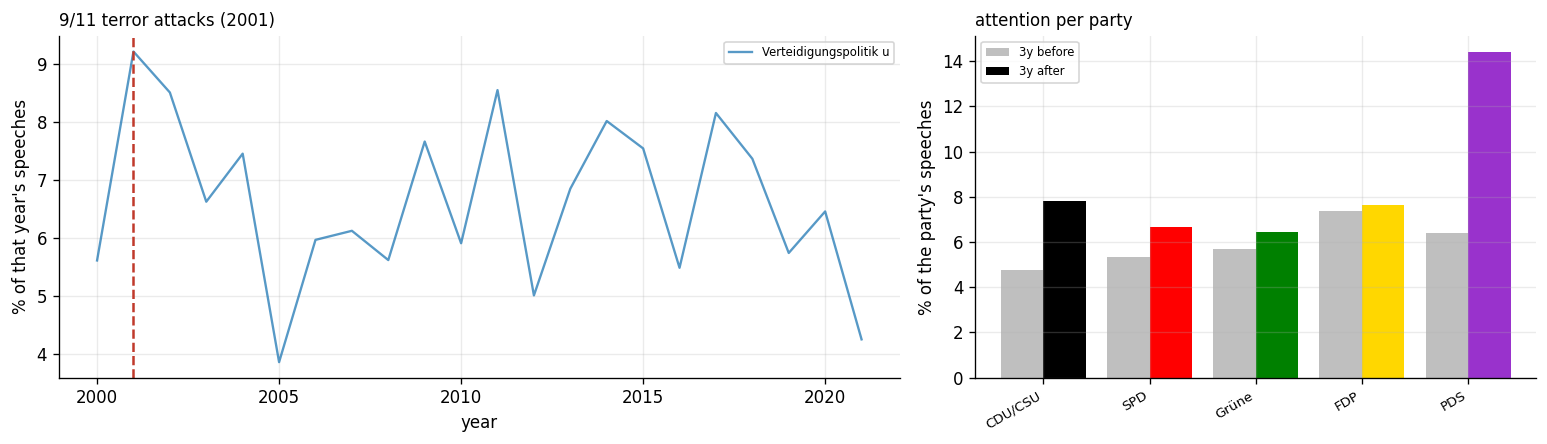

share of each party's speeches on these topics, % — 9/11 terror attacks
         Verteidigungspolitik u
party                          
AfD                        6.37
CDU/CSU                    6.40
FDP                        6.67
Grüne                      6.90
LINKE                      7.60
PDS                        9.66
SPD                        6.13 



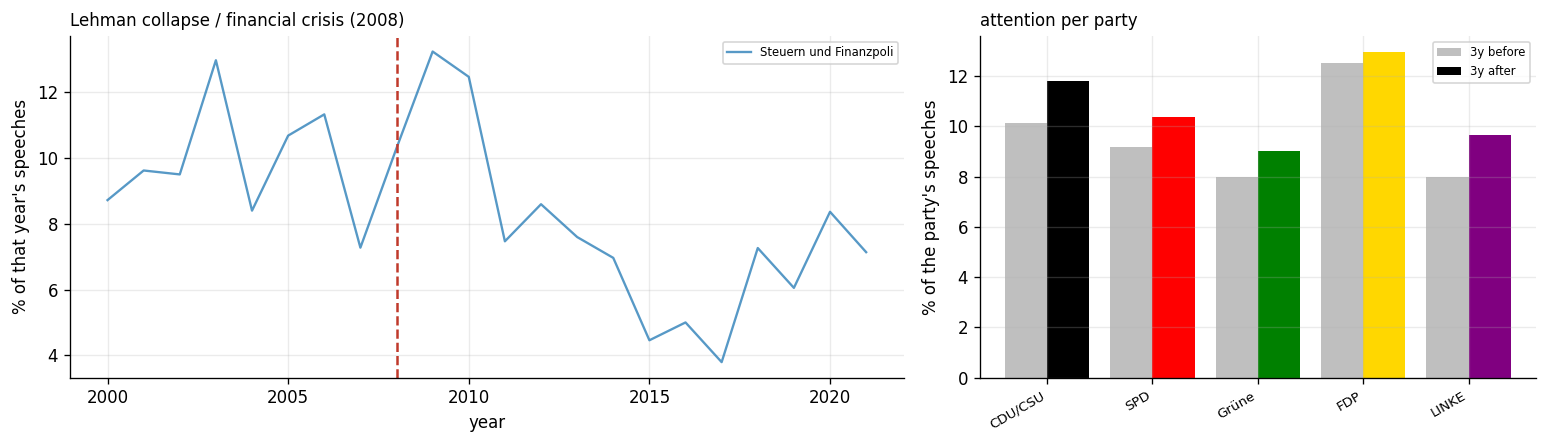

share of each party's speeches on these topics, % — Lehman collapse / financial crisis
         Steuern und Finanzpoli
party                          
AfD                        7.05
CDU/CSU                    8.59
FDP                       11.42
Grüne                      7.10
LINKE                      7.18
PDS                        7.57
SPD                        8.54 



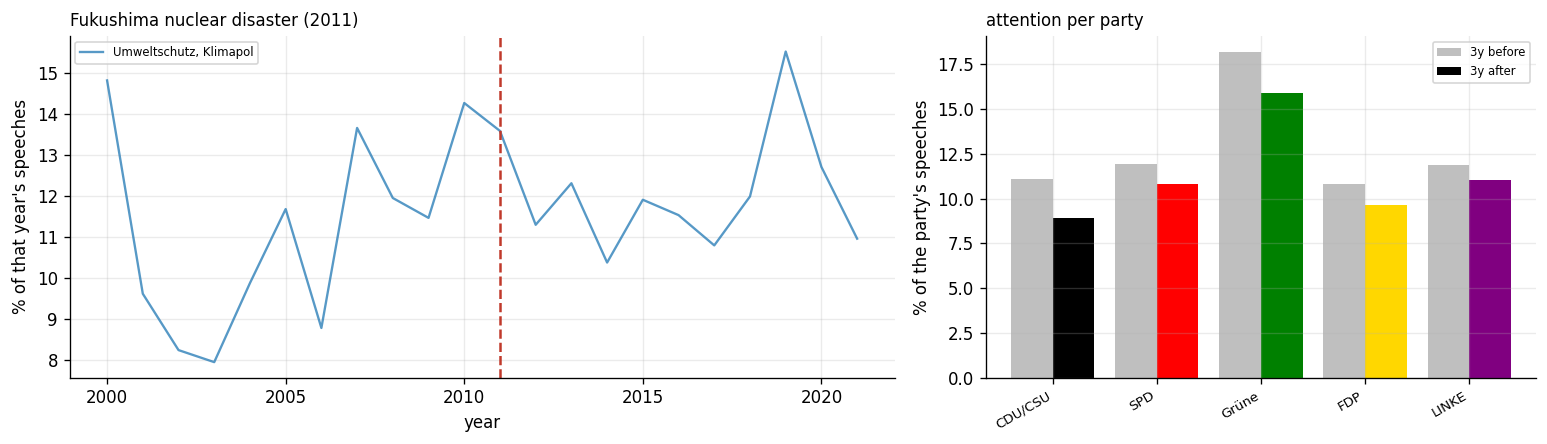

share of each party's speeches on these topics, % — Fukushima nuclear disaster
         Umweltschutz, Klimapol
party                          
AfD                       14.75
CDU/CSU                    9.89
FDP                       10.26
Grüne                     16.64
LINKE                     11.74
PDS                       10.94
SPD                       11.15 



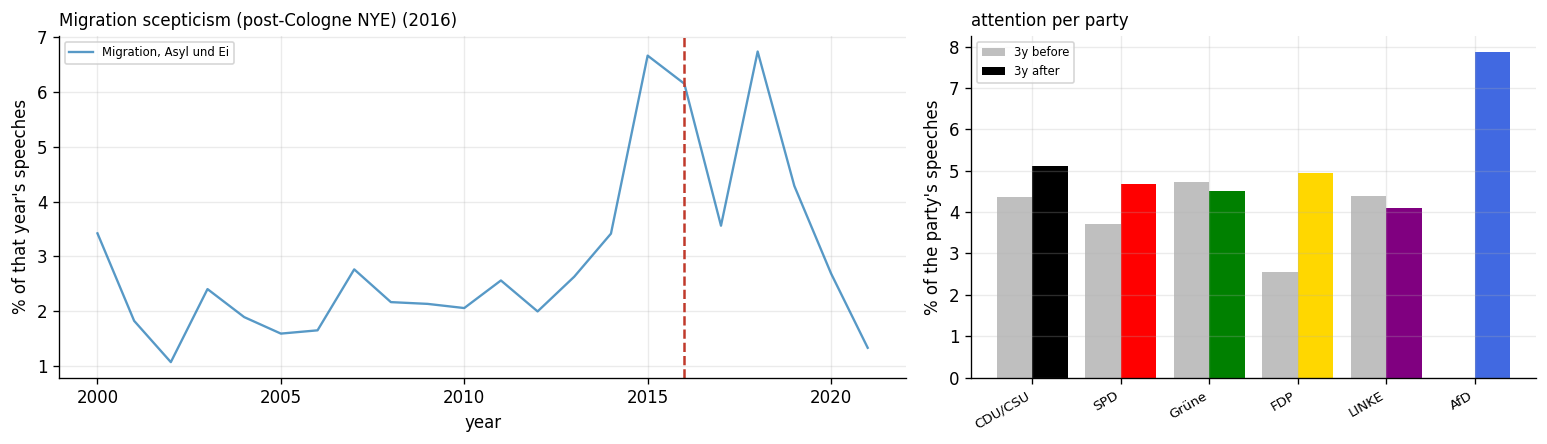

share of each party's speeches on these topics, % — Migration scepticism (post-Cologne NYE)
         Migration, Asyl und Ei
party                          
AfD                        5.95
CDU/CSU                    3.03
FDP                        2.35
Grüne                      3.46
LINKE                      3.48
PDS                        2.55
SPD                        2.68 



In [53]:
WINDOW = 3      # years before / after the event used for the party comparison

def frequency_figure(ev):
    "Attention to an event's topics: over time, and per party before vs after."
    on_topic = df.topic_emb_full_name.isin(ev["topics"])
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 3.8),
                                   gridspec_kw={"width_ratios": [1.5, 1]})

    # --- left: share of the year's speeches, one line per topic plus the total
    for t in ev["topics"]:
        share = df.topic_emb_full_name.eq(t).groupby(df.year).mean()
        ax1.plot(share.index, 100 * share.values, lw=1.4, alpha=.75,
                 label=t.split("/")[0][:22])
    if len(ev["topics"]) > 1:
        tot = on_topic.groupby(df.year).mean()
        ax1.plot(tot.index, 100 * tot.values, lw=2.4, color="0.2", label="all topics together")
    ax1.axvline(ev["year"], color="#c0392b", ls="--", lw=1.5)
    ax1.set_xlabel("year"); ax1.set_ylabel("% of that year's speeches")
    ax1.set_title(f"{ev['label']} ({ev['year']})", loc="left", fontsize=10)
    ax1.legend(fontsize=7)

    # --- right: per party, share of its own speeches, before vs after
    pre  = df[df.year.between(ev["year"] - WINDOW, ev["year"] - 1)]
    post = df[df.year.between(ev["year"] + 1, ev["year"] + WINDOW)]
    parties = [p for p in PARTY_COLORS if p in set(pre.party) | set(post.party)]
    b = [100 * pre.loc[pre.party == p, "topic_emb_full_name"].isin(ev["topics"]).mean()
         for p in parties]
    a = [100 * post.loc[post.party == p, "topic_emb_full_name"].isin(ev["topics"]).mean()
         for p in parties]
    x = np.arange(len(parties))
    ax2.bar(x - 0.2, b, 0.4, color="0.75", label=f"{WINDOW}y before")
    ax2.bar(x + 0.2, a, 0.4, color=[PARTY_COLORS[p] for p in parties], label=f"{WINDOW}y after")
    ax2.set_xticks(x); ax2.set_xticklabels(parties, rotation=30, ha="right", fontsize=8)
    ax2.set_ylabel("% of the party's speeches")
    ax2.set_title("attention per party", loc="left", fontsize=10)
    ax2.legend(fontsize=7)

    plt.tight_layout()
    slug = "".join(ch if ch.isalnum() else "_" for ch in ev["label"].lower())[:28]
    plt.savefig(f"fig_freq_{ev['year']}_{slug}.png", dpi=150, bbox_inches="tight")
    plt.show()

    # --- the same numbers as a table: party x topic, share of the party's speeches
    d = df[on_topic]
    tab = (100 * pd.crosstab(d.party, d.topic_emb_full_name).div(
           df.groupby("party").size(), axis=0)).round(2)
    tab.columns = [c.split("/")[0][:22] for c in tab.columns]
    print(f"share of each party's speeches on these topics, % — {ev['label']}")
    print(tab.to_string(), "\n")
    return tab


for ev in EVENTS:
    frequency_figure(ev)